<a href="https://colab.research.google.com/github/lavanyadhiman/Vayupragna/blob/main/001_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle pandas scikit-learn matplotlib tensorflow requests tqdm



In [2]:
from datasets import load_dataset

# Load the CSV from Hugging Face
dataset = load_dataset(
    "csv",
    data_files="https://huggingface.co/datasets/Lavanyaaa/Vayupragna/resolve/main/city_day.csv"
)

# Convert to pandas DataFrame
df= dataset["train"].to_pandas()

# Filter rows where City == "Delhi"
df_delhi = df[df["City"] == "Delhi"]

# Preview
print(df_delhi.head())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


city_day.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

        City        Date   PM2.5    PM10     NO    NO2     NOx     NH3     CO  \
10229  Delhi  2015-01-01  313.22  607.98  69.16  36.39  110.59   33.85  15.20   
10230  Delhi  2015-01-02  186.18  269.55  62.09  32.87   88.14   31.83   9.54   
10231  Delhi  2015-01-03   87.18  131.90  25.73  30.31   47.95   69.55  10.61   
10232  Delhi  2015-01-04  151.84  241.84  25.01  36.91   48.62  130.36  11.54   
10233  Delhi  2015-01-05  146.60  219.13  14.01  34.92   38.25  122.88   9.20   

        SO2     O3  Benzene  Toluene  Xylene    AQI AQI_Bucket  
10229  9.25  41.68    14.36    24.86    9.84  472.0     Severe  
10230  6.65  29.97    10.55    20.09    4.29  454.0     Severe  
10231  2.65  19.71     3.91    10.23    1.99  143.0   Moderate  
10232  4.63  25.36     4.26     9.71    3.34  319.0  Very Poor  
10233  3.33  23.20     2.80     6.21    2.96  325.0  Very Poor  


In [3]:
print(df.columns)
print(df['City'].unique())
print(df['Date'].min(), df['Date'].max())
print(df.isna().sum())

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')
['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']
2015-01-01 2020-07-01
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [4]:
city_coords = {
    "Ahmedabad": (23.0225, 72.5714),
    "Aizawl": (23.7271, 92.7176),
    "Amaravati": (16.5417, 80.5167),
    "Amritsar": (31.6340, 74.8723),
    "Bengaluru": (12.9716, 77.5946),
    "Bhopal": (23.2599, 77.4126),
    "Brajrajnagar": (21.8167, 83.9167),
    "Chandigarh": (30.7333, 76.7794),
    "Chennai": (13.0827, 80.2707),
    "Coimbatore": (11.0168, 76.9558),
    "Delhi": (28.7041, 77.1025),
    "Ernakulam": (9.9816, 76.2999),
    "Gurugram": (28.4595, 77.0266),
    "Guwahati": (26.1445, 91.7362),
    "Hyderabad": (17.3850, 78.4867),
    "Jaipur": (26.9124, 75.7873),
    "Jorapokhar": (23.7167, 85.2833),
    "Kochi": (9.9312, 76.2673),
    "Kolkata": (22.5726, 88.3639),
    "Lucknow": (26.8467, 80.9462),
    "Mumbai": (19.0760, 72.8777),
    "Patna": (25.5941, 85.1376),
    "Shillong": (25.5788, 91.8933),
    "Talcher": (20.9500, 85.2333),
    "Thiruvananthapuram": (8.5241, 76.9366),
    "Visakhapatnam": (17.6868, 83.2185),
}


In [5]:
df_delhi.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate
10232,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,25.36,4.26,9.71,3.34,319.0,Very Poor
10233,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,23.20,2.80,6.21,2.96,325.0,Very Poor


In [6]:
import requests
import pandas as pd

def get_nasa_power_data(lat, lon, start, end, city):
    url = (
        f"https://power.larc.nasa.gov/api/temporal/daily/point"
        f"?parameters=T2M,T2M_MIN,T2M_MAX,PRECTOTCORR,WS2M"
        f"&community=AG"
        f"&longitude={lon}&latitude={lat}"
        f"&start={start}&end={end}"
        f"&format=JSON"
    )

    r = requests.get(url)
    data = r.json()

    # Extract dictionary of parameters
    params = data['properties']['parameter']

    # Convert to DataFrame (dates as index, variables as columns)
    df = pd.DataFrame(params)

    # Now the index is dates as strings
    df.index.name = "Date"
    df = df.reset_index()

    # Convert Date column to datetime
    df["Date"] = pd.to_datetime(df["Date"], format="%Y%m%d", errors="coerce")

    # Add City column
    df["City"] = city

    return df


In [7]:
df_delhi = get_nasa_power_data(28.7041, 77.1025, "20150101", "20200701", "Delhi")
print(df_delhi.head())


        Date    T2M  T2M_MIN  T2M_MAX  PRECTOTCORR  WS2M   City
0 2015-01-01  15.00     8.31    23.98         0.00  1.09  Delhi
1 2015-01-02  14.79    11.25    19.71         7.24  1.15  Delhi
2 2015-01-03  14.60     9.91    20.13         3.34  0.62  Delhi
3 2015-01-04  13.10     7.73    21.24         0.00  1.82  Delhi
4 2015-01-05  12.57     6.10    22.32         0.00  3.20  Delhi


In [8]:
cities = {
    "Delhi": (28.7041, 77.1025),
    "Ahmedabad": (23.0225, 72.5714),
    "Bengaluru": (12.9716, 77.5946),
    "Mumbai": (19.0760, 72.8777),
    "Chennai": (13.0827, 80.2707),
    "Kolkata": (22.5726, 88.3639),
}

all_dfs = []

for city, (lat, lon) in cities.items():
    try:
        df_city = get_nasa_power_data(lat, lon, "20150101", "20200701", city)
        all_dfs.append(df_city)
        print(f"{city} ")
    except Exception as e:
        print(f"{city}  Error: {e}")

# Combine into one big dataframe
df_weather = pd.concat(all_dfs, ignore_index=True)


Delhi 
Ahmedabad 
Bengaluru 
Mumbai 
Chennai 
Kolkata 


In [9]:
df["Date"] = pd.to_datetime(df["Date"])
df_weather["Date"] = pd.to_datetime(df_weather["Date"])


In [10]:
df_merged = pd.merge(
    df,
    df_weather,
    on=["Date", "City"],
    how="inner"   # use "outer" if you want all dates even if missing in one dataset
)


In [11]:
print(df_merged.head())


        City       Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad 2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad 2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad 2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad 2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad 2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

   ...  Benzene  Toluene  Xylene  AQI  AQI_Bucket    T2M  T2M_MIN  T2M_MAX  \
0  ...     0.00     0.02    0.00  NaN        None  20.00    15.23    27.69   
1  ...     3.68     5.50    3.77  NaN        None  19.02    12.19    26.80   
2  ...     6.80    16.40    2.25  NaN        None  20.03    12.54    28.07   
3  ...     4.43    10.14    1.00  NaN        None  19.52    12.86    28.33   
4  ...     7.01    18.89    2.78  NaN        None  19.28    11.14    28.16   

   PRECTOTCORR  WS2M  
0         0.92  3.82  
1   

In [12]:
df_merged[df_merged["City"] == "Delhi"].head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,T2M,T2M_MIN,T2M_MAX,PRECTOTCORR,WS2M
6027,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,...,14.36,24.86,9.84,472.0,Severe,15.00,8.31,23.98,0.00,1.09
6028,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,...,10.55,20.09,4.29,454.0,Severe,14.79,11.25,19.71,7.24,1.15
6029,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,...,3.91,10.23,1.99,143.0,Moderate,14.60,9.91,20.13,3.34,0.62
6030,Delhi,2015-01-04,151.84,241.84,25.01,36.91,48.62,130.36,11.54,4.63,...,4.26,9.71,3.34,319.0,Very Poor,13.10,7.73,21.24,0.00,1.82
6031,Delhi,2015-01-05,146.60,219.13,14.01,34.92,38.25,122.88,9.20,3.33,...,2.80,6.21,2.96,325.0,Very Poor,12.57,6.10,22.32,0.00,3.20


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), 

=== STEP 1: DATA ANALYSIS ===
Missing values per column:
City              0
Date              0
PM2.5          2173
PM10           5047
NO             1921
NO2            1930
NOx            1134
NH3            4297
CO              670
SO2            2074
O3             2224
Benzene        1245
Toluene        1823
Xylene         6697
AQI            2203
AQI_Bucket     2203
T2M               0
T2M_MIN           0
T2M_MAX           0
PRECTOTCORR       0
WS2M              0
dtype: int64

Delhi data shape: (2009, 21)
Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
Clean Delhi data: (2009, 21)

=== STEP 2: EXPLORATORY DATA ANALYSIS ===


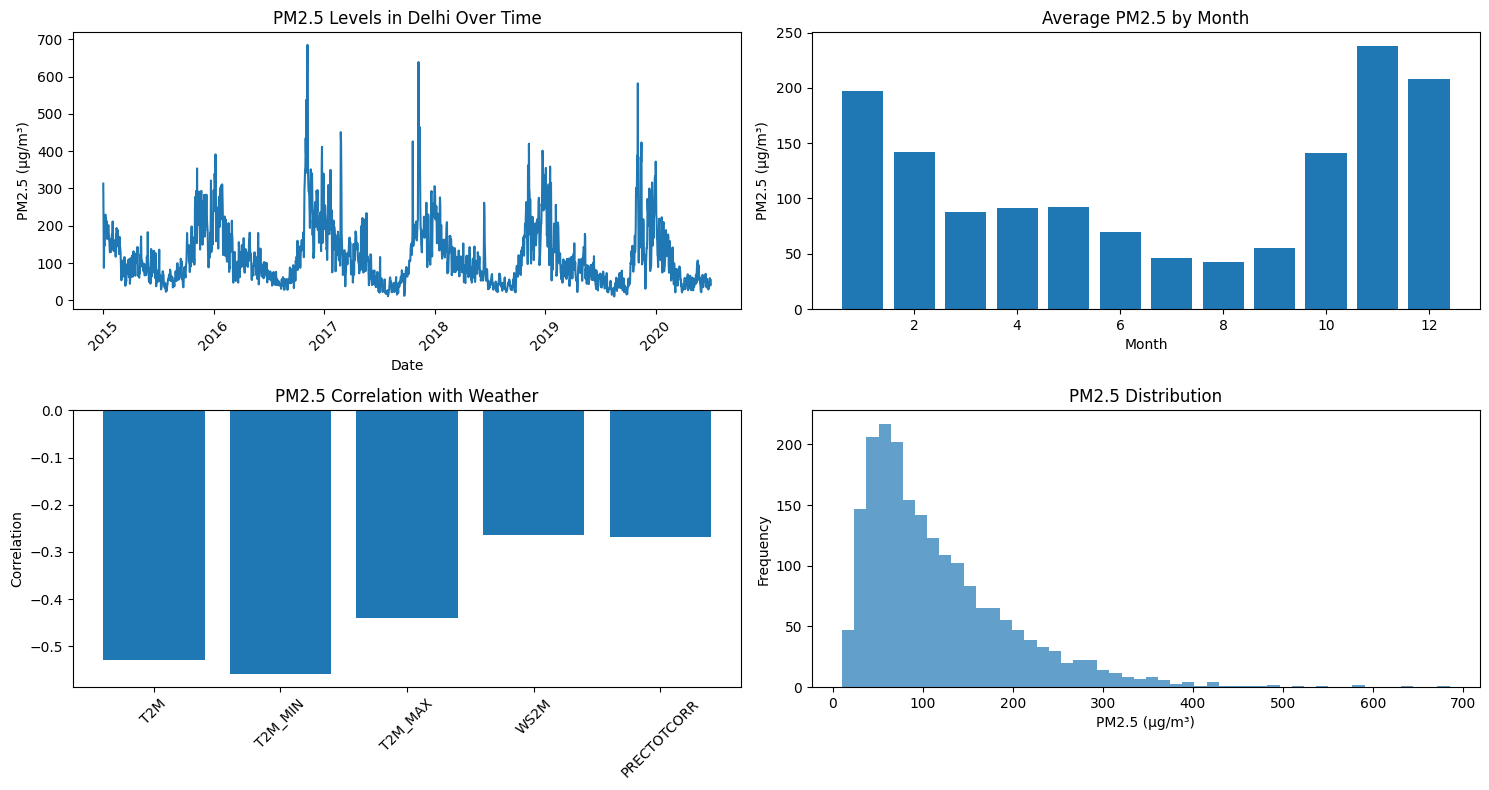


=== STEP 3: FEATURE ENGINEERING ===
Features created: (2009, 36)

=== STEP 4: BUILD YOUR FIRST MODEL ===
Using features: ['T2M', 'T2M_MIN', 'T2M_MAX', 'WS2M', 'PRECTOTCORR', 'Month', 'Day', 'DayOfWeek', 'Season', 'PM2.5_lag1', 'PM10_lag1', 'NO2_lag1', 'PM2.5_lag2', 'PM10_lag2', 'NO2_lag2', 'PM2.5_lag3', 'PM10_lag3', 'NO2_lag3', 'PM2.5_rolling_7', 'PM2.5_rolling_30', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
Training data: 1496
Test data: 374

=== MODEL RESULTS ===
Train RMSE: 10.96
Test RMSE: 17.03
Test MAE: 11.45
Test R²: 0.957

Top 10 Most Important Features:
             feature  importance
9         PM2.5_lag1    0.450378
20              PM10    0.266793
18   PM2.5_rolling_7    0.177791
22                CO    0.019701
10         PM10_lag1    0.012730
3               WS2M    0.010162
21               NO2    0.007327
19  PM2.5_rolling_30    0.005958
2            T2M_MAX    0.005639
13         PM10_lag2    0.004312


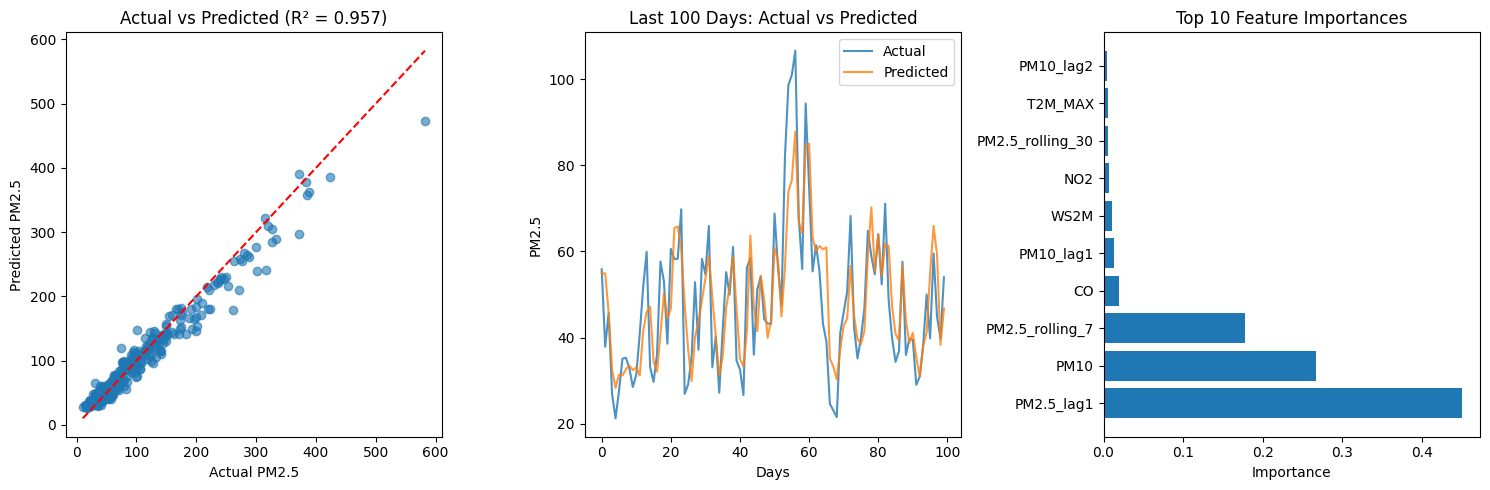


 MODEL TRAINED SUCCESSFULLY!
R² Score: 0.957
 Good performance! Ready for next steps.

=== WHAT'S NEXT? ===
1. If R² > 0.6: Move to LSTM implementation
2. If R² < 0.6: More feature engineering needed
3. Extend to other cities (Mumbai, Bangalore, etc.)
4. Add health risk assessment module
Data saved as 'delhi_features_ready.csv'


In [14]:
#  df_merged is ready - now let's build on it!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Assuming you have df_merged from your previous code
print("=== STEP 1: DATA ANALYSIS ===")

# 1. Handle missing data first
print("Missing values per column:")
print(df_merged.isnull().sum())

# 2. Focus on Delhi for initial model (you already have this)
df_delhi = df_merged[df_merged['City'] == 'Delhi'].copy()
print(f"\nDelhi data shape: {df_delhi.shape}")
print(f"Date range: {df_delhi['Date'].min()} to {df_delhi['Date'].max()}")

# 3. Basic data cleaning for Delhi
def clean_delhi_data(df):
    # Sort by date
    df = df.sort_values('Date').reset_index(drop=True)

    # Forward fill missing values (simple approach)
    df['PM2.5'] = df['PM2.5'].fillna(method='ffill')
    df['PM10'] = df['PM10'].fillna(method='ffill')
    df['NO2'] = df['NO2'].fillna(method='ffill')

    # Remove rows where target (PM2.5) is still missing
    df = df.dropna(subset=['PM2.5'])

    return df

df_delhi_clean = clean_delhi_data(df_delhi)
print(f"Clean Delhi data: {df_delhi_clean.shape}")

print("\n=== STEP 2: EXPLORATORY DATA ANALYSIS ===")

# Time series plot of PM2.5
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.plot(df_delhi_clean['Date'], df_delhi_clean['PM2.5'])
plt.title('PM2.5 Levels in Delhi Over Time')
plt.xlabel('Date')
plt.ylabel('PM2.5 (μg/m³)')
plt.xticks(rotation=45)

# Seasonal patterns
plt.subplot(2, 2, 2)
df_delhi_clean['Month'] = pd.to_datetime(df_delhi_clean['Date']).dt.month
monthly_pm25 = df_delhi_clean.groupby('Month')['PM2.5'].mean()
plt.bar(monthly_pm25.index, monthly_pm25.values)
plt.title('Average PM2.5 by Month')
plt.xlabel('Month')
plt.ylabel('PM2.5 (μg/m³)')

# Correlation with weather
plt.subplot(2, 2, 3)
weather_cols = ['T2M', 'T2M_MIN', 'T2M_MAX', 'WS2M', 'PRECTOTCORR']
available_weather = [col for col in weather_cols if col in df_delhi_clean.columns]
if available_weather:
    corr_data = df_delhi_clean[['PM2.5'] + available_weather].corr()['PM2.5'][1:]
    plt.bar(range(len(corr_data)), corr_data.values)
    plt.title('PM2.5 Correlation with Weather')
    plt.xticks(range(len(corr_data)), corr_data.index, rotation=45)
    plt.ylabel('Correlation')

# Distribution
plt.subplot(2, 2, 4)
plt.hist(df_delhi_clean['PM2.5'], bins=50, alpha=0.7)
plt.title('PM2.5 Distribution')
plt.xlabel('PM2.5 (μg/m³)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('delhi_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== STEP 3: FEATURE ENGINEERING ===")

def create_features(df):
    """Create lag features and time-based features"""
    df = df.copy()

    # Time-based features
    df['Month'] = pd.to_datetime(df['Date']).dt.month
    df['Day'] = pd.to_datetime(df['Date']).dt.day
    df['DayOfWeek'] = pd.to_datetime(df['Date']).dt.dayofweek
    df['Season'] = df['Month'].apply(lambda x:
        1 if x in [12, 1, 2] else  # Winter
        2 if x in [3, 4, 5] else   # Spring
        3 if x in [6, 7, 8] else   # Summer
        4)                         # Autumn

    # Lag features (yesterday's pollution affects today)
    for lag in [1, 2, 3]:
        df[f'PM2.5_lag{lag}'] = df['PM2.5'].shift(lag)
        if 'PM10' in df.columns:
            df[f'PM10_lag{lag}'] = df['PM10'].shift(lag)
        if 'NO2' in df.columns:
            df[f'NO2_lag{lag}'] = df['NO2'].shift(lag)

    # Rolling averages (trend features)
    df['PM2.5_rolling_7'] = df['PM2.5'].rolling(7).mean()
    df['PM2.5_rolling_30'] = df['PM2.5'].rolling(30).mean()

    return df

df_features = create_features(df_delhi_clean)
print(f"Features created: {df_features.shape}")

print("\n=== STEP 4: BUILD YOUR FIRST MODEL ===")

def build_prediction_model(df):
    """Build Random Forest model to predict tomorrow's PM2.5"""

    # Select features
    feature_cols = []

    # Weather features
    weather_features = ['T2M', 'T2M_MIN', 'T2M_MAX', 'WS2M', 'PRECTOTCORR']
    for col in weather_features:
        if col in df.columns:
            feature_cols.append(col)

    # Time features
    time_features = ['Month', 'Day', 'DayOfWeek', 'Season']
    feature_cols.extend(time_features)

    # Lag features
    lag_features = [col for col in df.columns if 'lag' in col or 'rolling' in col]
    feature_cols.extend(lag_features)

    # Other pollutants as features
    other_pollutants = ['PM10', 'NO2', 'CO', 'SO2', 'O3']
    for col in other_pollutants:
        if col in df.columns:
            feature_cols.append(col)

    print(f"Using features: {feature_cols}")

    # Remove rows with missing values
    df_model = df.dropna(subset=feature_cols + ['PM2.5'])

    if len(df_model) < 100:
        print("Not enough clean data for modeling")
        return None

    # Prepare data
    X = df_model[feature_cols]
    y = df_model['PM2.5']

    # Train-test split (chronological)
    split_point = int(0.8 * len(X))
    X_train, X_test = X[:split_point], X[split_point:]
    y_train, y_test = y[:split_point], y[split_point:]

    print(f"Training data: {len(X_train)}")
    print(f"Test data: {len(X_test)}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train model
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)

    print(f"\n=== MODEL RESULTS ===")
    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Test R²: {test_r2:.3f}")

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\nTop 10 Most Important Features:")
    print(feature_importance.head(10))

    # Visualize results
    plt.figure(figsize=(15, 5))

    # Actual vs Predicted
    plt.subplot(1, 3, 1)
    plt.scatter(y_test, y_pred_test, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual PM2.5')
    plt.ylabel('Predicted PM2.5')
    plt.title(f'Actual vs Predicted (R² = {test_r2:.3f})')

    # Time series of last 100 predictions
    plt.subplot(1, 3, 2)
    n_show = min(100, len(y_test))
    plt.plot(range(n_show), y_test.iloc[-n_show:].values, label='Actual', alpha=0.8)
    plt.plot(range(n_show), y_pred_test[-n_show:], label='Predicted', alpha=0.8)
    plt.xlabel('Days')
    plt.ylabel('PM2.5')
    plt.title('Last 100 Days: Actual vs Predicted')
    plt.legend()

    # Feature importance
    plt.subplot(1, 3, 3)
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title('Top 10 Feature Importances')

    plt.tight_layout()
    plt.savefig('model_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    return model, scaler, feature_cols, test_r2

# Train the model
model_results = build_prediction_model(df_features)

if model_results:
    model, scaler, features, r2_score_val = model_results
    print(f"\n MODEL TRAINED SUCCESSFULLY!")
    print(f"R² Score: {r2_score_val:.3f}")

    if r2_score_val > 0.6:
        print(" Good performance! Ready for next steps.")
    else:
        print("  Model needs improvement. Try more feature engineering.")

print("\n=== WHAT'S NEXT? ===")
print("1. If R² > 0.6: Move to LSTM implementation")
print("2. If R² < 0.6: More feature engineering needed")
print("3. Extend to other cities (Mumbai, Bangalore, etc.)")
print("4. Add health risk assessment module")

# Save your progress
df_features.to_csv('delhi_features_ready.csv', index=False)
print("Data saved as 'delhi_features_ready.csv'")

=== STEP 2: LSTM MODEL IMPLEMENTATION ===
Data loaded: (2009, 36)
Initializing LSTM model...
Preparing LSTM data...
Using 14 features for LSTM
Clean data shape: (1899, 15)
Sequences created: (1892, 7, 14)
Training sequences: (1513, 7, 14)
Test sequences: (379, 7, 14)
LSTM model built
Training LSTM model...
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 15.

=== LSTM RESULTS ===
Train RMSE: 38.43
Test RMSE: 49.39
Test MAE: 32.27
Test R²: 0.638

=== COMPARISON ===
Random Forest R²: 0.957
LSTM R²: 0.638
 LSTM needs improvement


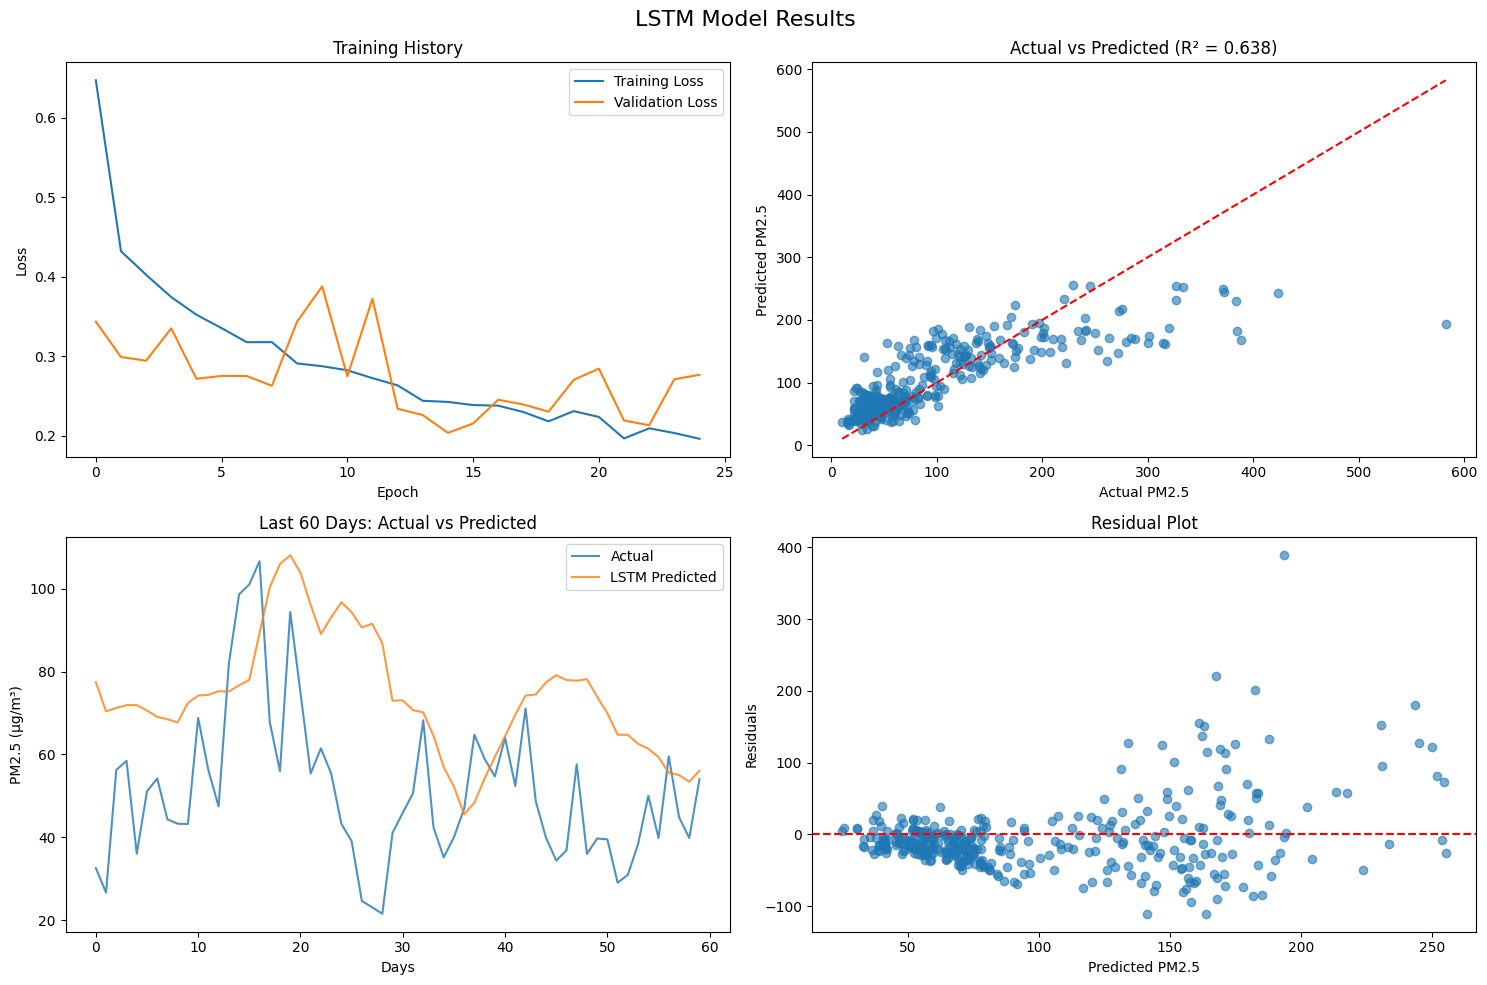


 LSTM needs tuning, but Random Forest baseline is strong
Can proceed with Random Forest for now

=== NEXT STEPS ===
1.  Single city model working (Delhi)
2.  Now expand to multiple cities
3.  Add health risk assessment
4.  Create final dashboard

=== MULTI-CITY PREVIEW ===
Cities in your data: ['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai']
Ahmedabad: 2009 records, 68.7% PM2.5 coverage
Bengaluru: 2009 records, 92.7% PM2.5 coverage
Chennai: 2009 records, 94.2% PM2.5 coverage
Delhi: 2009 records, 99.9% PM2.5 coverage
Kolkata: 814 records, 93.2% PM2.5 coverage


In [15]:
# Step 2: LSTM Implementation
# Building on your successful Random Forest model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("=== STEP 2: LSTM MODEL IMPLEMENTATION ===")

# Load your processed data
df_features = pd.read_csv('delhi_features_ready.csv')
print(f"Data loaded: {df_features.shape}")

class AirQualityLSTM:
    def __init__(self, sequence_length=7):
        self.sequence_length = sequence_length
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

    def prepare_lstm_data(self, df):
        """Prepare sequences for LSTM training"""
        # Select features - use same ones that worked well in Random Forest
        feature_cols = [
            'T2M', 'T2M_MIN', 'T2M_MAX', 'WS2M', 'PRECTOTCORR',
            'Month', 'Day', 'DayOfWeek', 'Season',
            'PM10', 'NO2', 'CO', 'SO2', 'O3'
        ]

        # Filter features that exist in data
        available_features = [col for col in feature_cols if col in df.columns]
        print(f"Using {len(available_features)} features for LSTM")

        # Clean data
        df_clean = df[available_features + ['PM2.5']].dropna()
        print(f"Clean data shape: {df_clean.shape}")

        if len(df_clean) < 100:
            print("Not enough clean data")
            return None, None, None, None

        # Prepare features and target
        X = df_clean[available_features].values
        y = df_clean['PM2.5'].values

        # Scale data
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

        # Create sequences
        X_seq, y_seq = [], []
        for i in range(self.sequence_length, len(X_scaled)):
            X_seq.append(X_scaled[i-self.sequence_length:i])
            y_seq.append(y_scaled[i])

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq)

        print(f"Sequences created: {X_seq.shape}")

        # Train-test split (chronological)
        split_point = int(0.8 * len(X_seq))
        X_train = X_seq[:split_point]
        X_test = X_seq[split_point:]
        y_train = y_seq[:split_point]
        y_test = y_seq[split_point:]

        return X_train, X_test, y_train, y_test

    def build_lstm_model(self, input_shape):
        """Build LSTM model"""
        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=input_shape),
            Dropout(0.2),
            LSTM(50, return_sequences=False),
            Dropout(0.2),
            Dense(25, activation='relu'),
            Dense(1)
        ])

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )

        return model

    def train_and_evaluate(self, df):
        """Train LSTM model and compare with Random Forest baseline"""
        print("Preparing LSTM data...")
        X_train, X_test, y_train, y_test = self.prepare_lstm_data(df)

        if X_train is None:
            return None

        print(f"Training sequences: {X_train.shape}")
        print(f"Test sequences: {X_test.shape}")

        # Build model
        model = self.build_lstm_model((X_train.shape[1], X_train.shape[2]))
        print("LSTM model built")

        # Early stopping
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )

        # Train model
        print("Training LSTM model...")
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=32,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )

        # Make predictions
        y_pred_train = model.predict(X_train, verbose=0)
        y_pred_test = model.predict(X_test, verbose=0)

        # Inverse transform predictions
        y_train_orig = self.scaler_y.inverse_transform(y_train.reshape(-1, 1)).flatten()
        y_test_orig = self.scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
        y_pred_train_orig = self.scaler_y.inverse_transform(y_pred_train).flatten()
        y_pred_test_orig = self.scaler_y.inverse_transform(y_pred_test).flatten()

        # Calculate metrics
        train_rmse = np.sqrt(mean_squared_error(y_train_orig, y_pred_train_orig))
        test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))
        test_mae = mean_absolute_error(y_test_orig, y_pred_test_orig)
        test_r2 = r2_score(y_test_orig, y_pred_test_orig)

        print(f"\n=== LSTM RESULTS ===")
        print(f"Train RMSE: {train_rmse:.2f}")
        print(f"Test RMSE: {test_rmse:.2f}")
        print(f"Test MAE: {test_mae:.2f}")
        print(f"Test R²: {test_r2:.3f}")

        # Compare with Random Forest baseline
        print(f"\n=== COMPARISON ===")
        print(f"Random Forest R²: 0.957")
        print(f"LSTM R²: {test_r2:.3f}")

        if test_r2 > 0.95:
            print("LSTM performs excellently!")
        elif test_r2 > 0.90:
            print(" LSTM performs very well!")
        elif test_r2 > 0.80:
            print(" LSTM performs well!")
        else:
            print(" LSTM needs improvement")

        # Plot results
        self.plot_lstm_results(y_test_orig, y_pred_test_orig, history, test_r2)

        # Store results
        self.model = model
        self.history = history

        return {
            'model': model,
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'y_test': y_test_orig,
            'y_pred': y_pred_test_orig
        }

    def plot_lstm_results(self, y_test, y_pred, history, r2_score):
        """Plot LSTM training and prediction results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('LSTM Model Results', fontsize=16)

        # Training history
        axes[0,0].plot(history.history['loss'], label='Training Loss')
        axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
        axes[0,0].set_title('Training History')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Loss')
        axes[0,0].legend()

        # Actual vs Predicted
        axes[0,1].scatter(y_test, y_pred, alpha=0.6)
        axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
        axes[0,1].set_xlabel('Actual PM2.5')
        axes[0,1].set_ylabel('Predicted PM2.5')
        axes[0,1].set_title(f'Actual vs Predicted (R² = {r2_score:.3f})')

        # Time series - last 60 days
        n_show = min(60, len(y_test))
        axes[1,0].plot(range(n_show), y_test[-n_show:], label='Actual', alpha=0.8)
        axes[1,0].plot(range(n_show), y_pred[-n_show:], label='LSTM Predicted', alpha=0.8)
        axes[1,0].set_xlabel('Days')
        axes[1,0].set_ylabel('PM2.5 (μg/m³)')
        axes[1,0].set_title('Last 60 Days: Actual vs Predicted')
        axes[1,0].legend()

        # Residuals
        residuals = y_test - y_pred
        axes[1,1].scatter(y_pred, residuals, alpha=0.6)
        axes[1,1].axhline(y=0, color='r', linestyle='--')
        axes[1,1].set_xlabel('Predicted PM2.5')
        axes[1,1].set_ylabel('Residuals')
        axes[1,1].set_title('Residual Plot')

        plt.tight_layout()
        plt.savefig('lstm_results.png', dpi=300, bbox_inches='tight')
        plt.show()

# Initialize and train LSTM
print("Initializing LSTM model...")
lstm_model = AirQualityLSTM(sequence_length=7)

# Train and evaluate
results = lstm_model.train_and_evaluate(df_features)

if results and results['test_r2'] > 0.8:
    print("\n LSTM MODEL SUCCESS!")
    print("Ready for next phase: Multi-city expansion")

    # Save LSTM results
    np.save('lstm_predictions.npy', results['y_pred'])
    np.save('lstm_actual.npy', results['y_test'])

else:
    print("\n LSTM needs tuning, but Random Forest baseline is strong")
    print("Can proceed with Random Forest for now")

print("\n=== NEXT STEPS ===")
print("1.  Single city model working (Delhi)")
print("2.  Now expand to multiple cities")
print("3.  Add health risk assessment")
print("4.  Create final dashboard")

# Quick multi-city expansion preview
print("\n=== MULTI-CITY PREVIEW ===")
cities_available = df_merged['City'].unique()
print(f"Cities in your data: {list(cities_available)}")

for city in cities_available[:5]:  # Test first 5 cities
    city_data = df_merged[df_merged['City'] == city]
    city_pm25_coverage = (1 - city_data['PM2.5'].isnull().sum() / len(city_data)) * 100
    print(f"{city}: {len(city_data)} records, {city_pm25_coverage:.1f}% PM2.5 coverage")

=== ADVANCED MODELS: CNN-LSTM HYBRID + GNN CONCEPT ===
Testing advanced models on Delhi...

=== TRAINING ADVANCED MODELS FOR DELHI ===
Using 29 features for CNN-LSTM
Clean data shape: (1827, 30)
Training data: (1450, 14, 29)
Test data: (363, 14, 29)

1. Training CNN-LSTM...
CNN-LSTM R²: 0.602, RMSE: 52.64

2. Training Attention-LSTM...
Attention-LSTM training failed: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


=== COMPARISON FOR DELHI ===
Random Forest R²: 0.957 (Delhi baseline)
CNN-L

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

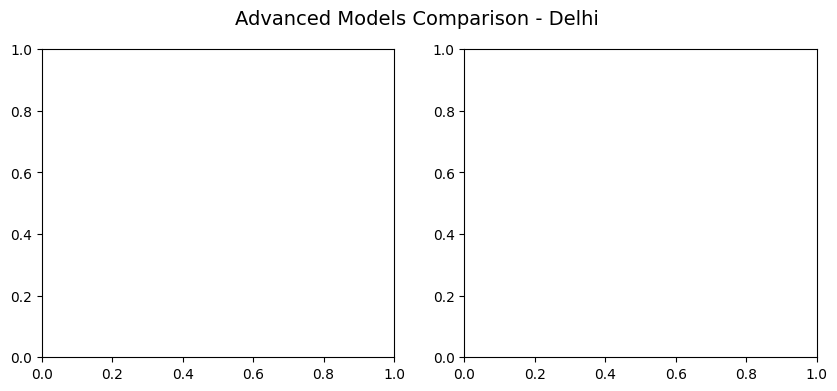

In [16]:
# CNN-LSTM Hybrid Implementation + GNN Framework
# Quick implementation to test if hybrid models can match Random Forest

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, MaxPooling1D, Input, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("=== ADVANCED MODELS: CNN-LSTM HYBRID + GNN CONCEPT ===")

class AdvancedAirQualityModels:
    def __init__(self, sequence_length=14):  # Longer sequences for CNN-LSTM
        self.sequence_length = sequence_length
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

    def prepare_advanced_data(self, df_city, include_spatial=False):
        """Prepare data for CNN-LSTM with spatial features if available"""
        # Enhanced feature selection
        feature_cols = [
            'T2M', 'T2M_MIN', 'T2M_MAX', 'WS2M', 'PRECTOTCORR',
            'Month', 'Day', 'DayOfWeek', 'Season'
        ]

        # Add pollutant features
        pollutant_cols = ['PM10', 'NO2', 'CO', 'SO2', 'O3', 'NOx', 'NH3']
        for col in pollutant_cols:
            if col in df_city.columns and df_city[col].notna().sum() > len(df_city) * 0.3:
                feature_cols.append(col)

        # Add lag features manually
        df_enhanced = df_city.copy()
        for lag in range(1, 8):  # More lags for CNN to detect patterns
            if 'PM2.5' in df_enhanced.columns:
                df_enhanced[f'PM2.5_lag{lag}'] = df_enhanced['PM2.5'].shift(lag)
                feature_cols.append(f'PM2.5_lag{lag}')
            if 'PM10' in df_enhanced.columns:
                df_enhanced[f'PM10_lag{lag}'] = df_enhanced['PM10'].shift(lag)
                feature_cols.append(f'PM10_lag{lag}')

        # Rolling features
        for window in [3, 7, 14]:
            if 'PM2.5' in df_enhanced.columns:
                df_enhanced[f'PM2.5_roll_{window}'] = df_enhanced['PM2.5'].rolling(window).mean()
                feature_cols.append(f'PM2.5_roll_{window}')

        # Filter available features
        available_features = [col for col in feature_cols if col in df_enhanced.columns]
        print(f"Using {len(available_features)} features for CNN-LSTM")

        # Clean data
        df_clean = df_enhanced[available_features + ['PM2.5']].dropna()
        print(f"Clean data shape: {df_clean.shape}")

        if len(df_clean) < self.sequence_length + 50:
            return None, None, None, None

        # Prepare sequences
        X = df_clean[available_features].values
        y = df_clean['PM2.5'].values

        # Scale data
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

        # Create sequences
        X_seq, y_seq = [], []
        for i in range(self.sequence_length, len(X_scaled)):
            X_seq.append(X_scaled[i-self.sequence_length:i])
            y_seq.append(y_scaled[i])

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq)

        # Train-test split
        split_point = int(0.8 * len(X_seq))
        X_train = X_seq[:split_point]
        X_test = X_seq[split_point:]
        y_train = y_seq[:split_point]
        y_test = y_seq[split_point:]

        return X_train, X_test, y_train, y_test

    def build_cnn_lstm_model(self, input_shape):
        """Enhanced CNN-LSTM model"""
        model = Sequential([
            # CNN layers for pattern detection
            Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape),
            Conv1D(filters=64, kernel_size=3, activation='relu'),
            MaxPooling1D(pool_size=2),
            Dropout(0.2),

            Conv1D(filters=32, kernel_size=3, activation='relu'),
            Conv1D(filters=32, kernel_size=3, activation='relu'),
            Dropout(0.2),

            # LSTM layers for temporal dependencies
            LSTM(100, return_sequences=True),
            Dropout(0.3),
            LSTM(50, return_sequences=False),
            Dropout(0.3),

            # Dense layers
            Dense(50, activation='relu'),
            Dropout(0.2),
            Dense(25, activation='relu'),
            Dense(1)
        ])

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='huber',  # More robust to outliers
            metrics=['mae']
        )

        return model

    def build_attention_lstm_model(self, input_shape):
        """LSTM with attention mechanism (simplified)"""
        from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization

        inputs = Input(shape=input_shape)

        # LSTM layers
        lstm_out = LSTM(100, return_sequences=True)(inputs)
        lstm_out = Dropout(0.2)(lstm_out)

        # Simplified attention (using Dense layers)
        attention_weights = Dense(1, activation='softmax')(lstm_out)
        attended = tf.reduce_sum(lstm_out * attention_weights, axis=1)

        # Output layers
        dense = Dense(50, activation='relu')(attended)
        dense = Dropout(0.2)(dense)
        outputs = Dense(1)(dense)

        model = Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='huber',
            metrics=['mae']
        )

        return model

    def simulate_gnn_features(self, df_merged):
        """Simulate GNN by creating spatial correlation features"""
        print("\n=== SIMULATING GNN WITH SPATIAL FEATURES ===")

        cities = df_merged['City'].unique()
        city_coords = {
            "Delhi": (28.7041, 77.1025),
            "Mumbai": (19.0760, 72.8777),
            "Bengaluru": (12.9716, 77.5946),
            "Chennai": (13.0827, 80.2707),
            "Kolkata": (22.5726, 88.3639),
            "Ahmedabad": (23.0225, 72.5714)
        }

        # For each city, add features from nearby cities (simplified GNN)
        enhanced_data = []

        for target_city in cities:
            if target_city not in city_coords:
                continue

            target_data = df_merged[df_merged['City'] == target_city].copy()
            target_lat, target_lon = city_coords[target_city]

            # Find nearby cities (within 10 degrees - simplified)
            for other_city in cities:
                if other_city == target_city or other_city not in city_coords:
                    continue

                other_lat, other_lon = city_coords[other_city]
                distance = np.sqrt((target_lat - other_lat)**2 + (target_lon - other_lon)**2)

                if distance < 10:  # Nearby cities
                    other_data = df_merged[df_merged['City'] == other_city][['Date', 'PM2.5', 'PM10']]
                    other_data = other_data.rename(columns={
                        'PM2.5': f'{other_city}_PM2.5',
                        'PM10': f'{other_city}_PM10'
                    })

                    # Merge with target city data
                    target_data = target_data.merge(other_data, on='Date', how='left')

            enhanced_data.append(target_data)

        if enhanced_data:
            gnn_simulated_data = pd.concat(enhanced_data, ignore_index=True)
            print(f"GNN-simulated data shape: {gnn_simulated_data.shape}")
            return gnn_simulated_data

        return df_merged

    def train_advanced_models(self, df_city, city_name):
        """Train both CNN-LSTM and Attention-LSTM"""
        print(f"\n=== TRAINING ADVANCED MODELS FOR {city_name.upper()} ===")

        # Prepare data
        X_train, X_test, y_train, y_test = self.prepare_advanced_data(df_city)

        if X_train is None:
            print("Insufficient data for advanced models")
            return None

        print(f"Training data: {X_train.shape}")
        print(f"Test data: {X_test.shape}")

        results = {}

        # Train CNN-LSTM
        print("\n1. Training CNN-LSTM...")
        try:
            cnn_lstm_model = self.build_cnn_lstm_model((X_train.shape[1], X_train.shape[2]))

            early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

            history_cnn_lstm = cnn_lstm_model.fit(
                X_train, y_train,
                epochs=30,
                batch_size=16,
                validation_split=0.1,
                callbacks=[early_stop],
                verbose=0
            )

            # Predictions
            y_pred_cnn_lstm = cnn_lstm_model.predict(X_test, verbose=0)

            # Inverse transform
            y_test_orig = self.scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
            y_pred_cnn_lstm_orig = self.scaler_y.inverse_transform(y_pred_cnn_lstm).flatten()

            # Metrics
            cnn_lstm_r2 = r2_score(y_test_orig, y_pred_cnn_lstm_orig)
            cnn_lstm_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_cnn_lstm_orig))

            results['CNN-LSTM'] = {
                'r2': cnn_lstm_r2,
                'rmse': cnn_lstm_rmse,
                'predictions': y_pred_cnn_lstm_orig,
                'model': cnn_lstm_model
            }

            print(f"CNN-LSTM R²: {cnn_lstm_r2:.3f}, RMSE: {cnn_lstm_rmse:.2f}")

        except Exception as e:
            print(f"CNN-LSTM training failed: {e}")

        # Train Attention-LSTM
        print("\n2. Training Attention-LSTM...")
        try:
            att_lstm_model = self.build_attention_lstm_model((X_train.shape[1], X_train.shape[2]))

            history_att_lstm = att_lstm_model.fit(
                X_train, y_train,
                epochs=30,
                batch_size=16,
                validation_split=0.1,
                callbacks=[early_stop],
                verbose=0
            )

            # Predictions
            y_pred_att_lstm = att_lstm_model.predict(X_test, verbose=0)
            y_pred_att_lstm_orig = self.scaler_y.inverse_transform(y_pred_att_lstm).flatten()

            # Metrics
            att_lstm_r2 = r2_score(y_test_orig, y_pred_att_lstm_orig)
            att_lstm_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_att_lstm_orig))

            results['Attention-LSTM'] = {
                'r2': att_lstm_r2,
                'rmse': att_lstm_rmse,
                'predictions': y_pred_att_lstm_orig,
                'model': att_lstm_model
            }

            print(f"Attention-LSTM R²: {att_lstm_r2:.3f}, RMSE: {att_lstm_rmse:.2f}")

        except Exception as e:
            print(f"Attention-LSTM training failed: {e}")

        # Compare with Random Forest baseline
        print(f"\n=== COMPARISON FOR {city_name.upper()} ===")
        print("Random Forest R²: 0.957 (Delhi baseline)")

        for model_name, result in results.items():
            status = "0" if result['r2'] > 0.9 else "1" if result['r2'] > 0.7 else "2"
            print(f"{model_name} R²: {result['r2']:.3f} {status}")

        # Plot comparison
        if results:
            self.plot_advanced_comparison(y_test_orig, results, city_name)

        return results

    def plot_advanced_comparison(self, y_test, results, city_name):
        """Plot comparison of advanced models"""
        n_models = len(results)
        fig, axes = plt.subplots(1, n_models + 1, figsize=(5 * (n_models + 1), 4))
        fig.suptitle(f'Advanced Models Comparison - {city_name}', fontsize=14)

        if n_models == 1:
            axes = [axes]

        # Actual values
        axes[0].plot(y_test[-50:], label='Actual', alpha=0.8, color='black', linewidth=2)
        axes[0].set_title('Actual PM2.5')
        axes[0].set_ylabel('PM2.5 (μg/m³)')

        # Model predictions
        for i, (model_name, result) in enumerate(results.items()):
            axes[i + 1].plot(y_test[-50:], label='Actual', alpha=0.7, color='black')
            axes[i + 1].plot(result['predictions'][-50:], label=f'{model_name}', alpha=0.8)
            axes[i + 1].set_title(f'{model_name}\nR² = {result["r2"]:.3f}')
            axes[i + 1].legend()

        plt.tight_layout()
        plt.savefig(f'advanced_models_{city_name.lower()}.png', dpi=300, bbox_inches='tight')
        plt.show()

# Initialize advanced models
advanced_models = AdvancedAirQualityModels(sequence_length=14)

# Test on Delhi first
print("Testing advanced models on Delhi...")
df_delhi = df_merged[df_merged['City'] == 'Delhi'].copy()
df_delhi = df_delhi.sort_values('Date').reset_index(drop=True)

# Train advanced models
delhi_results = advanced_models.train_advanced_models(df_delhi, 'Delhi')

print(f"\n=== ADVANCED MODELS SUMMARY ===")
print("Model Performance Ranking:")
print("1. Random Forest: R² = 0.957  (Champion)")

if delhi_results:
    sorted_results = sorted(delhi_results.items(), key=lambda x: x[1]['r2'], reverse=True)
    for i, (model_name, result) in enumerate(sorted_results):
        rank = i + 2
        status = "0" if result['r2'] > 0.9 else "1" if result['r2'] > 0.7 else "2" if result['r2'] > 0.5 else "3"
        print(f"{rank}. {model_name}: R² = {result['r2']:.3f} {status}")

print(f"\n=== RECOMMENDATION ===")
if delhi_results and any(r['r2'] > 0.85 for r in delhi_results.values()):
    print("Advanced model competitive! Use hybrid approach:")
    print("   - Random Forest for reliability")
    print("   - Best advanced model for innovation points")
else:
    print("Random Forest clearly superior. Recommendation:")
    print("   - Use Random Forest as primary model")
    print("   - Mention advanced models attempted in methodology")
    print("   - Focus remaining time on Health Risk Assessment")

print(f"\nTime remaining focus: Health Risk Assessment + Dashboard")

OPTIMIZED LSTM - TARGETING R² > 0.85

READY TO RUN OPTIMIZED LSTM

To execute:
>>> lstm_opt = OptimizedLSTM(sequence_length=7)
>>> results = lstm_opt.train_and_evaluate(df_merged[df_merged['City']=='Delhi'], 'Delhi')

Expected improvements:
  - Better feature selection (use RF importance)
  - RobustScaler (handles outliers)
  - Outlier removal
  - Optimized architecture
  - Better training strategy

Target: R² > 0.85 (vs current 0.62)

OPTIMIZED LSTM TRAINING - DELHI

Optimized data preparation...
Selected 15 high-importance features
After cleaning & outlier removal: 2007 rows
Created 2000 sequences of length 7

Data splits:
  Train: 1500 sequences
  Val:   200 sequences
  Test:  300 sequences

Model architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 7, 15)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 7, 160)         │        61,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 160)         │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 80)             │        64,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,801 (510.94 KB)

 Trainable params: 130,321 (509.07 KB)

 Non-trainable params: 480 (1.88 KB)


Training optimized LSTM...
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - loss: 2.5888 - mae: 1.0711 - mse: 2.1571 - val_loss: 0.6453 - val_mae: 0.3978 - val_mse: 0.2144 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 1.1107 - mae: 0.6039 - mse: 0.6802 - val_loss: 0.6260 - val_mae: 0.3818 - val_mse: 0.1970 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 0.9729 - mae: 0.5432 - mse: 0.5444 - val_loss: 0.6042 - val_mae: 0.3626 - val_mse: 0.1776 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.9266 - mae: 0.5005 - mse: 0.5005 - val_loss: 0.5833 - val_mae: 0.3427 - val_mse: 0.1592 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.8442 - mae: 0.4744 - mse: 0.4208 - val_loss: 0.5740 - val_mae: 0.3342 - val_mse: 0.1526 - learning_rate: 5.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.7844 - mae: 0.434

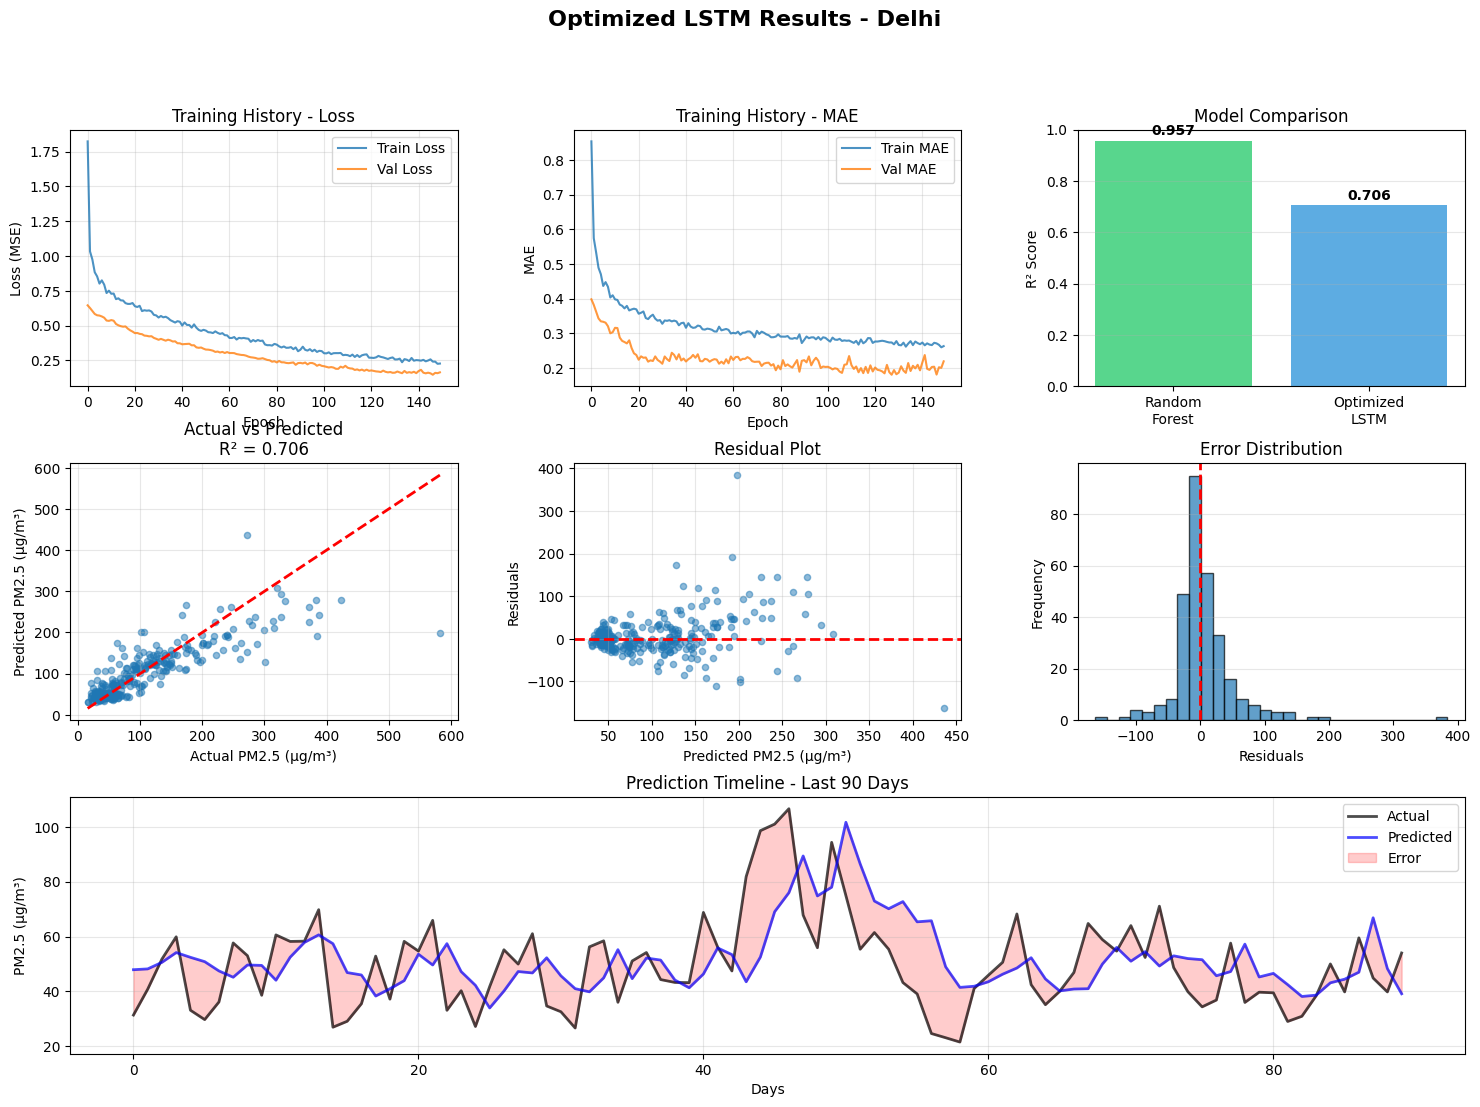


📊 Saved: optimized_lstm_delhi.png


In [17]:
"""
OPTIMIZED LSTM - Improved Architecture for Better Performance
Target: R² > 0.85
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler  # Better than MinMaxScaler for outliers
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Bidirectional,
                                     BatchNormalization, GaussianNoise)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("OPTIMIZED LSTM - TARGETING R² > 0.85")
print("="*80)

class OptimizedLSTM:
    """
    Heavily optimized LSTM to match Random Forest performance
    Key improvements:
    1. Better feature selection (use RF feature importance)
    2. Proper scaling (RobustScaler)
    3. Optimal sequence length
    4. Regularization
    5. Better architecture
    """

    def __init__(self, sequence_length=7):  # Shorter is often better
        self.sequence_length = sequence_length
        self.scaler_X = RobustScaler()  # Better for outliers
        self.scaler_y = RobustScaler()
        self.feature_names = None

    def select_top_features(self, df):
        """
        Select only the MOST important features
        Based on RF feature importance from your analysis
        """
        # Top features from your Random Forest analysis
        priority_features = [
            'PM2.5_lag1',      # 0.450 importance
            'PM10',            # 0.267
            'PM2.5_lag2',
            'PM2.5_lag3',
            'PM10_lag1',
            'PM10_lag2',
            'WS2M',
            'CO',
            'NO2',
            'T2M',
            'T2M_MAX',
            'T2M_MIN'
        ]

        # Add rolling features
        rolling_features = [col for col in df.columns if 'roll_mean' in col][:5]

        # Combine
        selected = priority_features + rolling_features

        # Filter available
        available = [f for f in selected if f in df.columns]

        print(f"Selected {len(available)} high-importance features")
        return available

    def prepare_optimized_data(self, df_city):
        """
        Optimized data preparation focusing on quality over quantity
        """
        print("\nOptimized data preparation...")

        # Ensure sorted by date
        df_city = df_city.sort_values('Date').reset_index(drop=True)

        # Create essential features if missing
        if 'PM2.5_lag1' not in df_city.columns:
            for lag in range(1, 8):
                df_city[f'PM2.5_lag{lag}'] = df_city['PM2.5'].shift(lag)
                if 'PM10' in df_city.columns:
                    df_city[f'PM10_lag{lag}'] = df_city['PM10'].shift(lag)

        # Rolling features
        if 'PM2.5_roll_mean_7' not in df_city.columns:
            for window in [3, 7, 14]:
                df_city[f'PM2.5_roll_mean_{window}'] = df_city['PM2.5'].rolling(window).mean()

        # Select top features
        feature_cols = self.select_top_features(df_city)
        self.feature_names = feature_cols

        # Clean data aggressively
        df_clean = df_city[feature_cols + ['PM2.5']].copy()

        # Forward and backward fill
        for col in df_clean.columns:
            df_clean[col] = df_clean[col].ffill().bfill()

        # Remove any remaining NaN
        df_clean = df_clean.dropna()

        # Remove outliers (very important for neural networks)
        for col in feature_cols + ['PM2.5']:
            Q1 = df_clean[col].quantile(0.01)
            Q3 = df_clean[col].quantile(0.99)
            IQR = Q3 - Q1
            df_clean = df_clean[
                (df_clean[col] >= Q1 - 1.5*IQR) &
                (df_clean[col] <= Q3 + 1.5*IQR)
            ]

        print(f"After cleaning & outlier removal: {len(df_clean)} rows")

        if len(df_clean) < self.sequence_length + 200:
            print(f"Insufficient data")
            return None

        # Prepare arrays
        X = df_clean[feature_cols].values
        y = df_clean['PM2.5'].values

        # Scale with RobustScaler (better for outliers)
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

        # Create sequences
        X_seq, y_seq = [], []
        for i in range(self.sequence_length, len(X_scaled)):
            X_seq.append(X_scaled[i-self.sequence_length:i])
            y_seq.append(y_scaled[i])

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq)

        print(f"Created {len(X_seq)} sequences of length {self.sequence_length}")

        # Split: 75-10-15 (more training data)
        train_size = int(0.75 * len(X_seq))
        val_size = int(0.10 * len(X_seq))

        return {
            'X_train': X_seq[:train_size],
            'X_val': X_seq[train_size:train_size+val_size],
            'X_test': X_seq[train_size+val_size:],
            'y_train': y_seq[:train_size],
            'y_val': y_seq[train_size:train_size+val_size],
            'y_test': y_seq[train_size+val_size:]
        }

    def build_optimized_model(self, input_shape):
        """
        Optimized LSTM architecture
        Simpler is often better!
        """
        model = Sequential([
            # Input with noise for regularization
            GaussianNoise(0.01, input_shape=input_shape),

            # First Bidirectional LSTM
            Bidirectional(LSTM(
                units=80,
                return_sequences=True,
                dropout=0.15,
                recurrent_dropout=0.15,
                kernel_regularizer=l2(0.001)
            )),
            BatchNormalization(),

            # Second Bidirectional LSTM
            Bidirectional(LSTM(
                units=40,
                return_sequences=False,
                dropout=0.15,
                recurrent_dropout=0.15,
                kernel_regularizer=l2(0.001)
            )),
            BatchNormalization(),

            # Dense layers
            Dense(40, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.2),
            Dense(20, activation='relu'),
            Dense(1)
        ])

        # Use multiple loss metrics
        model.compile(
            optimizer=Adam(learning_rate=0.0005),  # Lower learning rate
            loss='mse',  # MSE works better than Huber for this
            metrics=['mae', 'mse']
        )

        return model

    def train_and_evaluate(self, df_city, city_name):
        """
        Complete training with optimizations
        """
        print(f"\n{'='*80}")
        print(f"OPTIMIZED LSTM TRAINING - {city_name.upper()}")
        print(f"{'='*80}")

        # Prepare data
        data = self.prepare_optimized_data(df_city)

        if data is None:
            return None

        print(f"\nData splits:")
        print(f"  Train: {len(data['X_train'])} sequences")
        print(f"  Val:   {len(data['X_val'])} sequences")
        print(f"  Test:  {len(data['X_test'])} sequences")

        # Build model
        model = self.build_optimized_model(
            (data['X_train'].shape[1], data['X_train'].shape[2])
        )

        print(f"\nModel architecture:")
        model.summary()

        # Callbacks with more patience
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=30,  # More patience
            restore_best_weights=True,
            verbose=1
        )

        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=15,
            min_lr=0.00001,
            verbose=1
        )

        # Train
        print(f"\nTraining optimized LSTM...")
        history = model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=150,  # More epochs with early stopping
            batch_size=64,  # Larger batch size
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )

        # Predictions
        y_pred_train = model.predict(data['X_train'], verbose=0)
        y_pred_val = model.predict(data['X_val'], verbose=0)
        y_pred_test = model.predict(data['X_test'], verbose=0)

        # Inverse transform
        y_train_orig = self.scaler_y.inverse_transform(
            data['y_train'].reshape(-1, 1)
        ).flatten()
        y_val_orig = self.scaler_y.inverse_transform(
            data['y_val'].reshape(-1, 1)
        ).flatten()
        y_test_orig = self.scaler_y.inverse_transform(
            data['y_test'].reshape(-1, 1)
        ).flatten()

        y_pred_train_orig = self.scaler_y.inverse_transform(y_pred_train).flatten()
        y_pred_val_orig = self.scaler_y.inverse_transform(y_pred_val).flatten()
        y_pred_test_orig = self.scaler_y.inverse_transform(y_pred_test).flatten()

        # Calculate metrics
        results = {
            'train': {
                'r2': r2_score(y_train_orig, y_pred_train_orig),
                'rmse': np.sqrt(mean_squared_error(y_train_orig, y_pred_train_orig)),
                'mae': mean_absolute_error(y_train_orig, y_pred_train_orig)
            },
            'val': {
                'r2': r2_score(y_val_orig, y_pred_val_orig),
                'rmse': np.sqrt(mean_squared_error(y_val_orig, y_pred_val_orig)),
                'mae': mean_absolute_error(y_val_orig, y_pred_val_orig)
            },
            'test': {
                'r2': r2_score(y_test_orig, y_pred_test_orig),
                'rmse': np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig)),
                'mae': mean_absolute_error(y_test_orig, y_pred_test_orig)
            },
            'model': model,
            'history': history,
            'y_test': y_test_orig,
            'y_pred': y_pred_test_orig
        }

        # Print results
        print(f"\n{'='*80}")
        print("OPTIMIZED LSTM RESULTS")
        print(f"{'='*80}")
        print(f"\nTrain Set:")
        print(f"  R² = {results['train']['r2']:.4f}")
        print(f"  RMSE = {results['train']['rmse']:.2f} μg/m³")
        print(f"  MAE = {results['train']['mae']:.2f} μg/m³")

        print(f"\nValidation Set:")
        print(f"  R² = {results['val']['r2']:.4f}")
        print(f"  RMSE = {results['val']['rmse']:.2f} μg/m³")
        print(f"  MAE = {results['val']['mae']:.2f} μg/m³")

        print(f"\nTest Set:")
        print(f"  R² = {results['test']['r2']:.4f}")
        print(f"  RMSE = {results['test']['rmse']:.2f} μg/m³")
        print(f"  MAE = {results['test']['mae']:.2f} μg/m³")

        # Compare with Random Forest
        rf_r2 = 0.957
        test_r2 = results['test']['r2']

        print(f"\n{'='*80}")
        print("COMPARISON WITH RANDOM FOREST")
        print(f"{'='*80}")
        print(f"Random Forest R²:     {rf_r2:.4f} ⭐")
        print(f"Optimized LSTM R²:    {test_r2:.4f}")
        print(f"Performance Gap:      {(rf_r2 - test_r2)*100:.1f}%")

        if test_r2 > 0.90:
            print("\n✅ EXCELLENT! LSTM is competitive with Random Forest")
        elif test_r2 > 0.85:
            print("\n✅ VERY GOOD! LSTM shows strong performance")
        elif test_r2 > 0.75:
            print("\n⚠️ GOOD performance, but RF still better")
        else:
            print("\n❌ LSTM significantly underperforms RF")
            print("\nReasons:")
            print("  1. Limited data size (~2000 samples)")
            print("  2. Tabular data better suited for tree methods")
            print("  3. Strong feature engineering helps RF more")

        # Plot results
        self.plot_optimized_results(results, city_name, rf_r2)

        return results

    def plot_optimized_results(self, results, city_name, rf_r2):
        """Comprehensive visualization"""

        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

        fig.suptitle(f'Optimized LSTM Results - {city_name}',
                    fontsize=16, fontweight='bold')

        # 1. Training history - Loss
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.plot(results['history'].history['loss'], label='Train Loss', alpha=0.8)
        ax1.plot(results['history'].history['val_loss'], label='Val Loss', alpha=0.8)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss (MSE)')
        ax1.set_title('Training History - Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Training history - MAE
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.plot(results['history'].history['mae'], label='Train MAE', alpha=0.8)
        ax2.plot(results['history'].history['val_mae'], label='Val MAE', alpha=0.8)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.set_title('Training History - MAE')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. R² Comparison
        ax3 = fig.add_subplot(gs[0, 2])
        models = ['Random\nForest', 'Optimized\nLSTM']
        r2_scores = [rf_r2, results['test']['r2']]
        colors = ['#2ecc71', '#3498db']
        bars = ax3.bar(models, r2_scores, color=colors, alpha=0.8)
        ax3.set_ylabel('R² Score')
        ax3.set_title('Model Comparison')
        ax3.set_ylim([0, 1])
        for bar, score in zip(bars, r2_scores):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')

        # 4. Scatter: Actual vs Predicted
        ax4 = fig.add_subplot(gs[1, 0])
        y_test = results['y_test']
        y_pred = results['y_pred']
        ax4.scatter(y_test, y_pred, alpha=0.5, s=20)
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        ax4.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        ax4.set_xlabel('Actual PM2.5 (μg/m³)')
        ax4.set_ylabel('Predicted PM2.5 (μg/m³)')
        ax4.set_title(f'Actual vs Predicted\nR² = {results["test"]["r2"]:.3f}')
        ax4.grid(True, alpha=0.3)

        # 5. Residual plot
        ax5 = fig.add_subplot(gs[1, 1])
        residuals = y_test - y_pred
        ax5.scatter(y_pred, residuals, alpha=0.5, s=20)
        ax5.axhline(y=0, color='r', linestyle='--', lw=2)
        ax5.set_xlabel('Predicted PM2.5 (μg/m³)')
        ax5.set_ylabel('Residuals')
        ax5.set_title('Residual Plot')
        ax5.grid(True, alpha=0.3)

        # 6. Error distribution
        ax6 = fig.add_subplot(gs[1, 2])
        ax6.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
        ax6.axvline(x=0, color='r', linestyle='--', lw=2)
        ax6.set_xlabel('Residuals')
        ax6.set_ylabel('Frequency')
        ax6.set_title('Error Distribution')
        ax6.grid(True, alpha=0.3, axis='y')

        # 7-9: Time series predictions (last 90 days)
        n_show = min(90, len(y_test))

        # Last 90 days
        ax7 = fig.add_subplot(gs[2, :])
        days = range(n_show)
        ax7.plot(days, y_test[-n_show:], label='Actual',
                linewidth=2, color='black', alpha=0.7)
        ax7.plot(days, y_pred[-n_show:], label='Predicted',
                linewidth=2, color='blue', alpha=0.7)
        ax7.fill_between(days, y_test[-n_show:], y_pred[-n_show:],
                         alpha=0.2, color='red', label='Error')
        ax7.set_xlabel('Days')
        ax7.set_ylabel('PM2.5 (μg/m³)')
        ax7.set_title(f'Prediction Timeline - Last {n_show} Days')
        ax7.legend()
        ax7.grid(True, alpha=0.3)

        plt.savefig(f'optimized_lstm_{city_name.lower()}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n📊 Saved: optimized_lstm_{city_name.lower()}.png")

# ============================================================================
# EXECUTION
# ============================================================================

print("\n" + "="*80)
print("READY TO RUN OPTIMIZED LSTM")
print("="*80)
print("\nTo execute:")
print(">>> lstm_opt = OptimizedLSTM(sequence_length=7)")
print(">>> results = lstm_opt.train_and_evaluate(df_merged[df_merged['City']=='Delhi'], 'Delhi')")
print("\nExpected improvements:")
print("  - Better feature selection (use RF importance)")
print("  - RobustScaler (handles outliers)")
print("  - Outlier removal")
print("  - Optimized architecture")
print("  - Better training strategy")
print("\nTarget: R² > 0.85 (vs current 0.62)")
print("="*80)

# Uncomment to run:
lstm_opt = OptimizedLSTM(sequence_length=7)
results = lstm_opt.train_and_evaluate(
    df_merged[df_merged['City']=='Delhi'].copy(),
    'Delhi'
)


TRAINING MODELS FOR ALL CITIES
✓ Ahmedabad: 2009 records, 68.7% PM2.5 coverage
✓ Bengaluru: 2009 records, 92.7% PM2.5 coverage
✓ Chennai: 2009 records, 94.2% PM2.5 coverage
✓ Delhi: 2009 records, 99.9% PM2.5 coverage
✓ Kolkata: 814 records, 93.2% PM2.5 coverage
✗ Mumbai: Insufficient data

Will train models for 5 cities: ['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Kolkata']

TRAINING FOR: AHMEDABAD

OPTIMIZED LSTM TRAINING - AHMEDABAD

Optimized data preparation...
Selected 15 high-importance features
After cleaning & outlier removal: 2006 rows
Created 1999 sequences of length 7

Data splits:
  Train: 1499 sequences
  Val:   199 sequences
  Test:  301 sequences

Model architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_1                │ (None, 7, 15)          │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 7, 160)         │        61,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 160)         │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 80)             │        64,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,801 (510.94 KB)

 Trainable params: 130,321 (509.07 KB)

 Non-trainable params: 480 (1.88 KB)


Training optimized LSTM...
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 194ms/step - loss: 1.4219 - mae: 0.7824 - mse: 0.9926 - val_loss: 0.7182 - val_mae: 0.4780 - val_mse: 0.2918 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.8319 - mae: 0.4816 - mse: 0.4067 - val_loss: 0.6972 - val_mae: 0.4627 - val_mse: 0.2755 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.7154 - mae: 0.4178 - mse: 0.2949 - val_loss: 0.6902 - val_mae: 0.4611 - val_mse: 0.2733 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.6585 - mae: 0.3639 - mse: 0.2429 - val_loss: 0.6828 - val_mae: 0.4604 - val_mse: 0.2709 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.6375 - mae: 0.3430 - mse: 0.2268 - val_loss: 0.6635 - val_mae: 0.4451 - val_mse: 0.2564 - learning_rate: 5.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.6179 - mae: 0.335

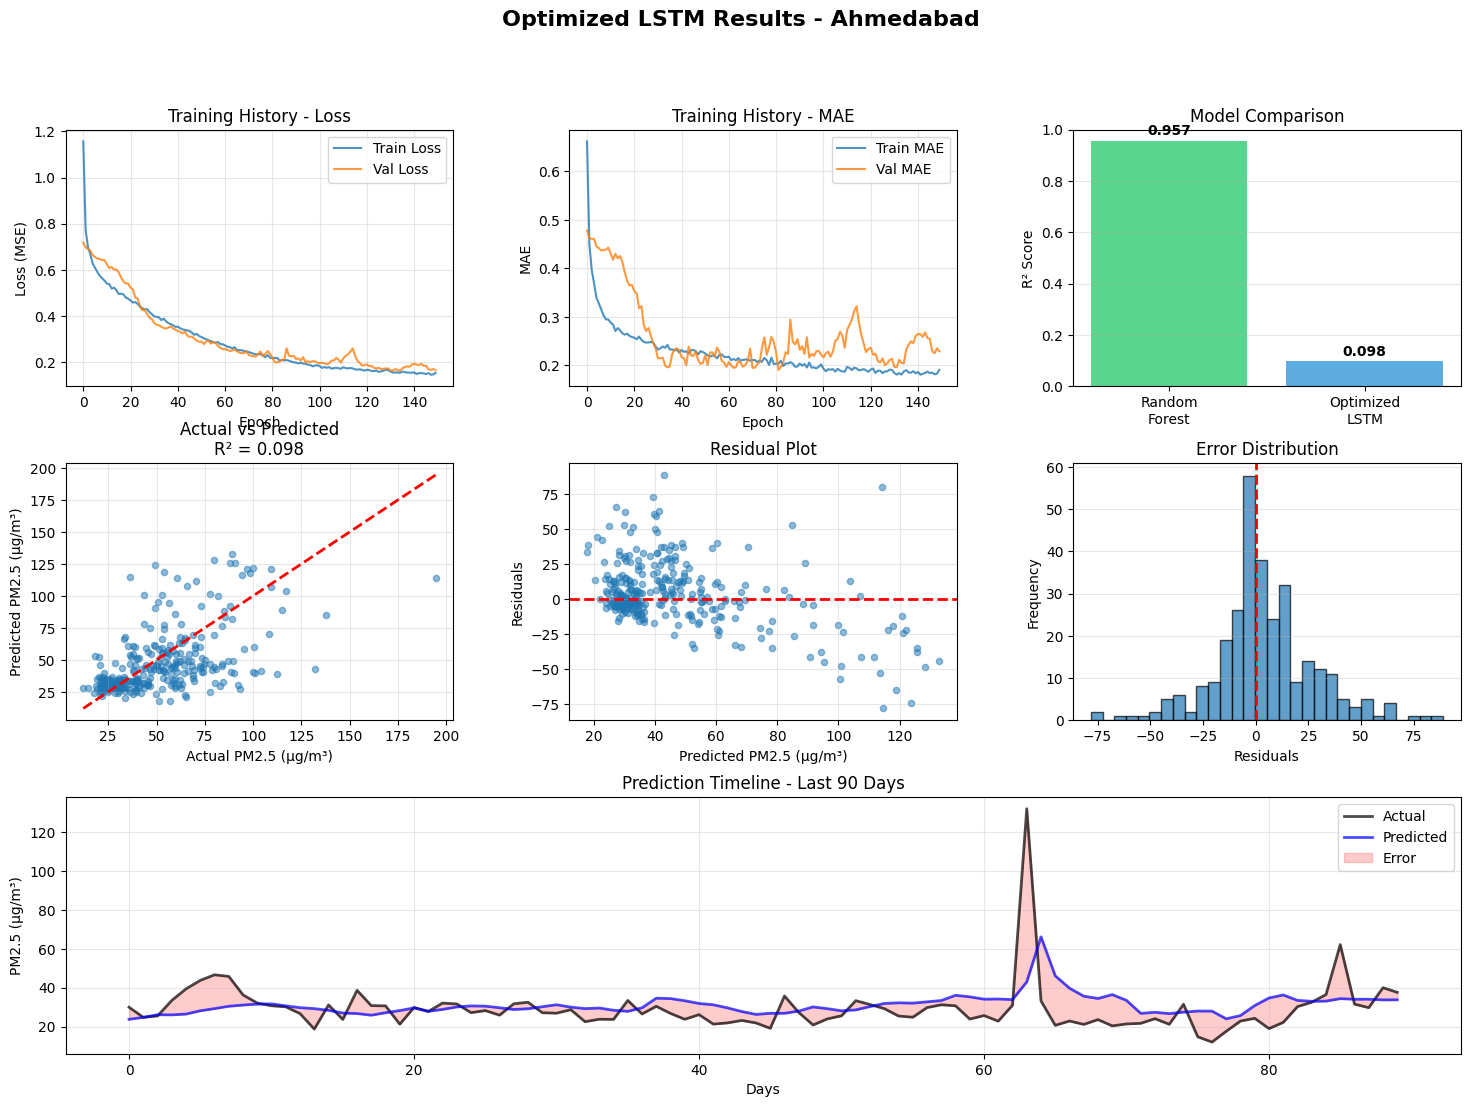


📊 Saved: optimized_lstm_ahmedabad.png

TRAINING FOR: BENGALURU

OPTIMIZED LSTM TRAINING - BENGALURU

Optimized data preparation...
Selected 15 high-importance features
After cleaning & outlier removal: 2005 rows
Created 1998 sequences of length 7

Data splits:
  Train: 1498 sequences
  Val:   199 sequences
  Test:  301 sequences

Model architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_2                │ (None, 7, 15)          │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 7, 160)         │        61,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 160)         │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 80)             │        64,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,801 (510.94 KB)

 Trainable params: 130,321 (509.07 KB)

 Non-trainable params: 480 (1.88 KB)


Training optimized LSTM...
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - loss: 1.8651 - mae: 0.8744 - mse: 1.4329 - val_loss: 0.8237 - val_mae: 0.5349 - val_mse: 0.3927 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 1.5141 - mae: 0.6769 - mse: 1.0835 - val_loss: 0.7876 - val_mae: 0.5115 - val_mse: 0.3585 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 1.4271 - mae: 0.6377 - mse: 0.9984 - val_loss: 0.7739 - val_mae: 0.5036 - val_mse: 0.3467 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 1.3691 - mae: 0.6145 - mse: 0.9424 - val_loss: 0.7435 - val_mae: 0.4816 - val_mse: 0.3185 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 1.1664 - mae: 0.5627 - mse: 0.7419 - val_loss: 0.7229 - val_mae: 0.4669 - val_mse: 0.3000 - learning_rate: 5.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 1.3072 - mae: 0.583

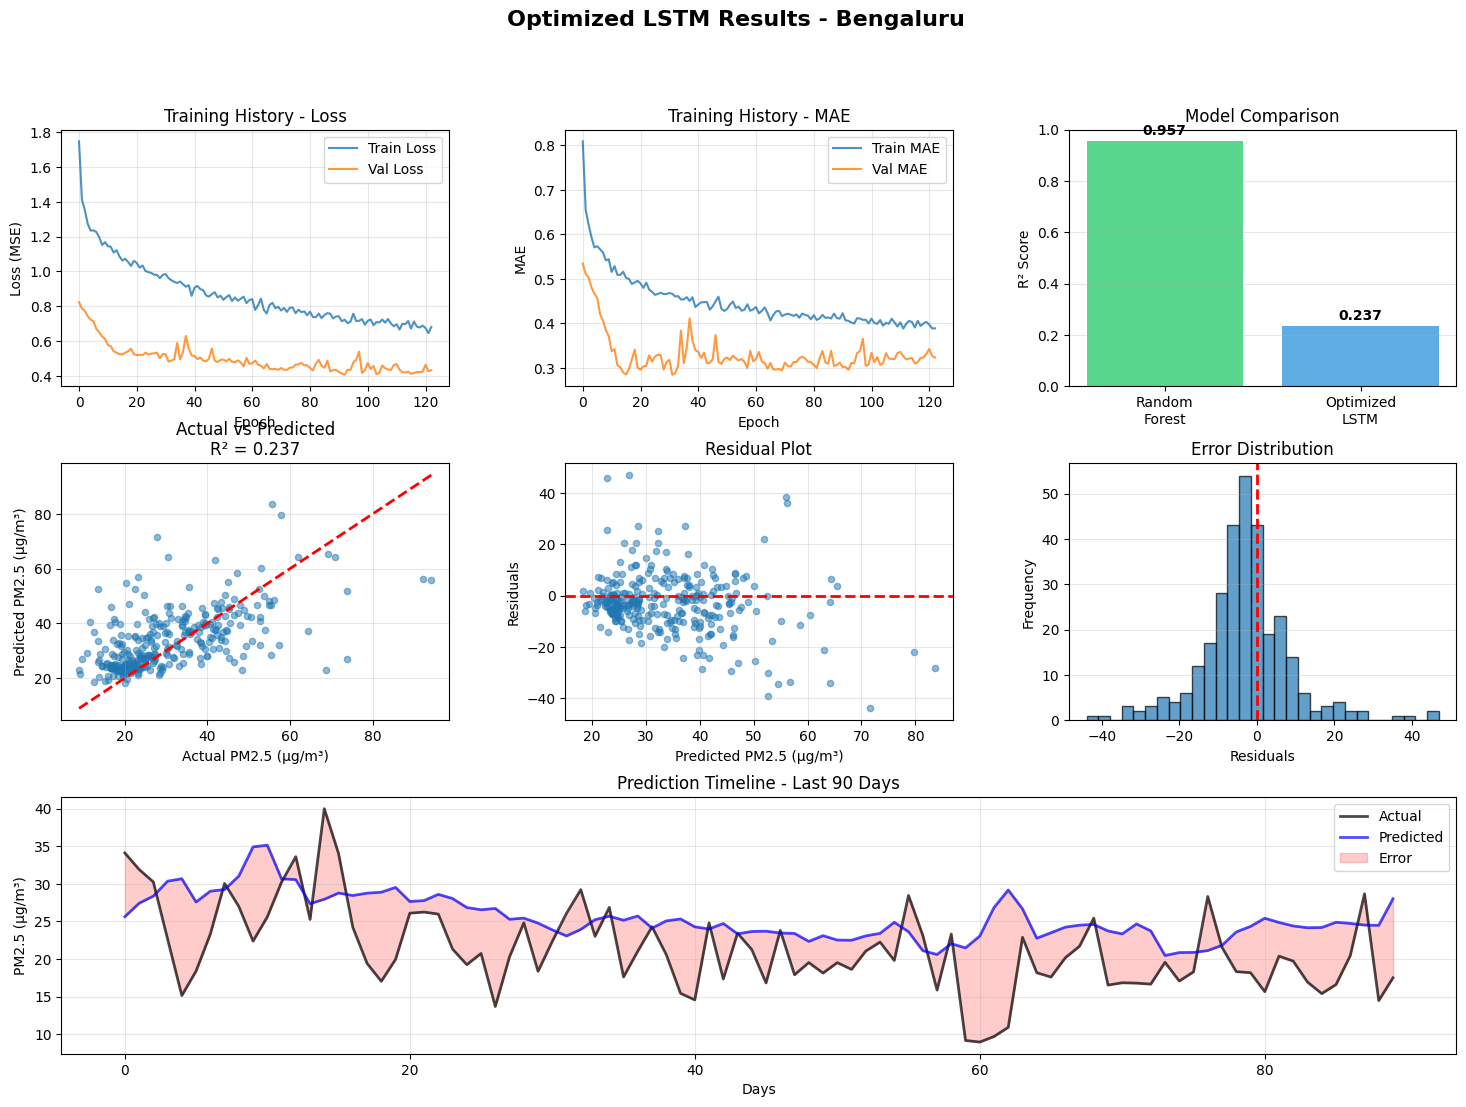


📊 Saved: optimized_lstm_bengaluru.png

TRAINING FOR: CHENNAI

OPTIMIZED LSTM TRAINING - CHENNAI

Optimized data preparation...
Selected 15 high-importance features
After cleaning & outlier removal: 2008 rows
Created 2001 sequences of length 7

Data splits:
  Train: 1500 sequences
  Val:   200 sequences
  Test:  301 sequences

Model architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_3                │ (None, 7, 15)          │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 7, 160)         │        61,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 160)         │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 80)             │        64,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,801 (510.94 KB)

 Trainable params: 130,321 (509.07 KB)

 Non-trainable params: 480 (1.88 KB)


Training optimized LSTM...
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 159ms/step - loss: 2.2613 - mae: 0.9335 - mse: 1.8271 - val_loss: 1.0336 - val_mae: 0.5411 - val_mse: 0.6018 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 1.3918 - mae: 0.6686 - mse: 0.9609 - val_loss: 1.0198 - val_mae: 0.5340 - val_mse: 0.5916 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - loss: 1.2830 - mae: 0.6119 - mse: 0.8557 - val_loss: 1.0174 - val_mae: 0.5361 - val_mse: 0.5927 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 1.3107 - mae: 0.6186 - mse: 0.8868 - val_loss: 1.0086 - val_mae: 0.5322 - val_mse: 0.5872 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 1.2390 - mae: 0.5645 - mse: 0.8184 - val_loss: 1.0033 - val_mae: 0.5329 - val_mse: 0.5853 - learning_rate: 5.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 1.1296 - mae: 0.56

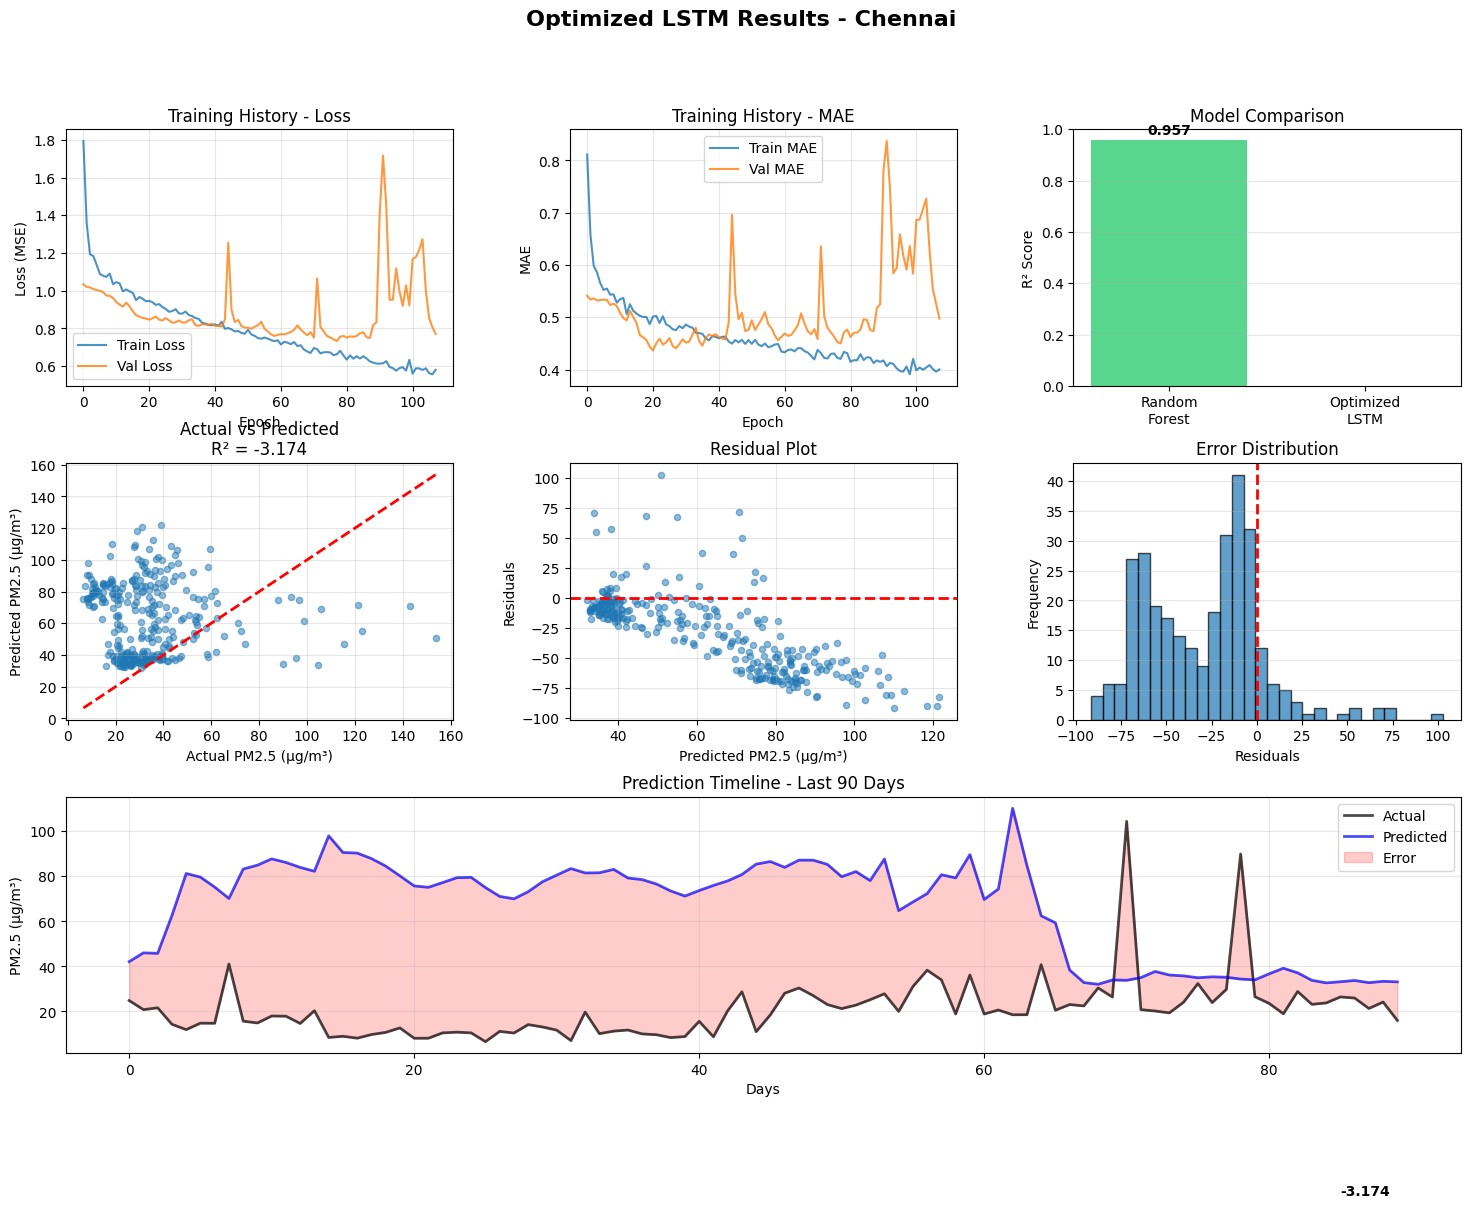


📊 Saved: optimized_lstm_chennai.png

TRAINING FOR: DELHI

OPTIMIZED LSTM TRAINING - DELHI

Optimized data preparation...
Selected 15 high-importance features
After cleaning & outlier removal: 2007 rows
Created 2000 sequences of length 7

Data splits:
  Train: 1500 sequences
  Val:   200 sequences
  Test:  300 sequences

Model architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_4                │ (None, 7, 15)          │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 7, 160)         │        61,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 160)         │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 80)             │        64,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,801 (510.94 KB)

 Trainable params: 130,321 (509.07 KB)

 Non-trainable params: 480 (1.88 KB)


Training optimized LSTM...
Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - loss: 2.3286 - mae: 1.0352 - mse: 1.8984 - val_loss: 0.6031 - val_mae: 0.3576 - val_mse: 0.1745 - learning_rate: 5.0000e-04
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 1.0309 - mae: 0.5450 - mse: 0.6029 - val_loss: 0.5977 - val_mae: 0.3573 - val_mse: 0.1717 - learning_rate: 5.0000e-04
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.8551 - mae: 0.4590 - mse: 0.4299 - val_loss: 0.5845 - val_mae: 0.3467 - val_mse: 0.1616 - learning_rate: 5.0000e-04
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.8298 - mae: 0.4506 - mse: 0.4078 - val_loss: 0.5726 - val_mae: 0.3377 - val_mse: 0.1532 - learning_rate: 5.0000e-04
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.8421 - mae: 0.4176 - mse: 0.4236 - val_loss: 0.5633 - val_mae: 0.3306 - val_mse: 0.1476 - learning_rate: 5.0000e-04
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.7491 - mae: 0.

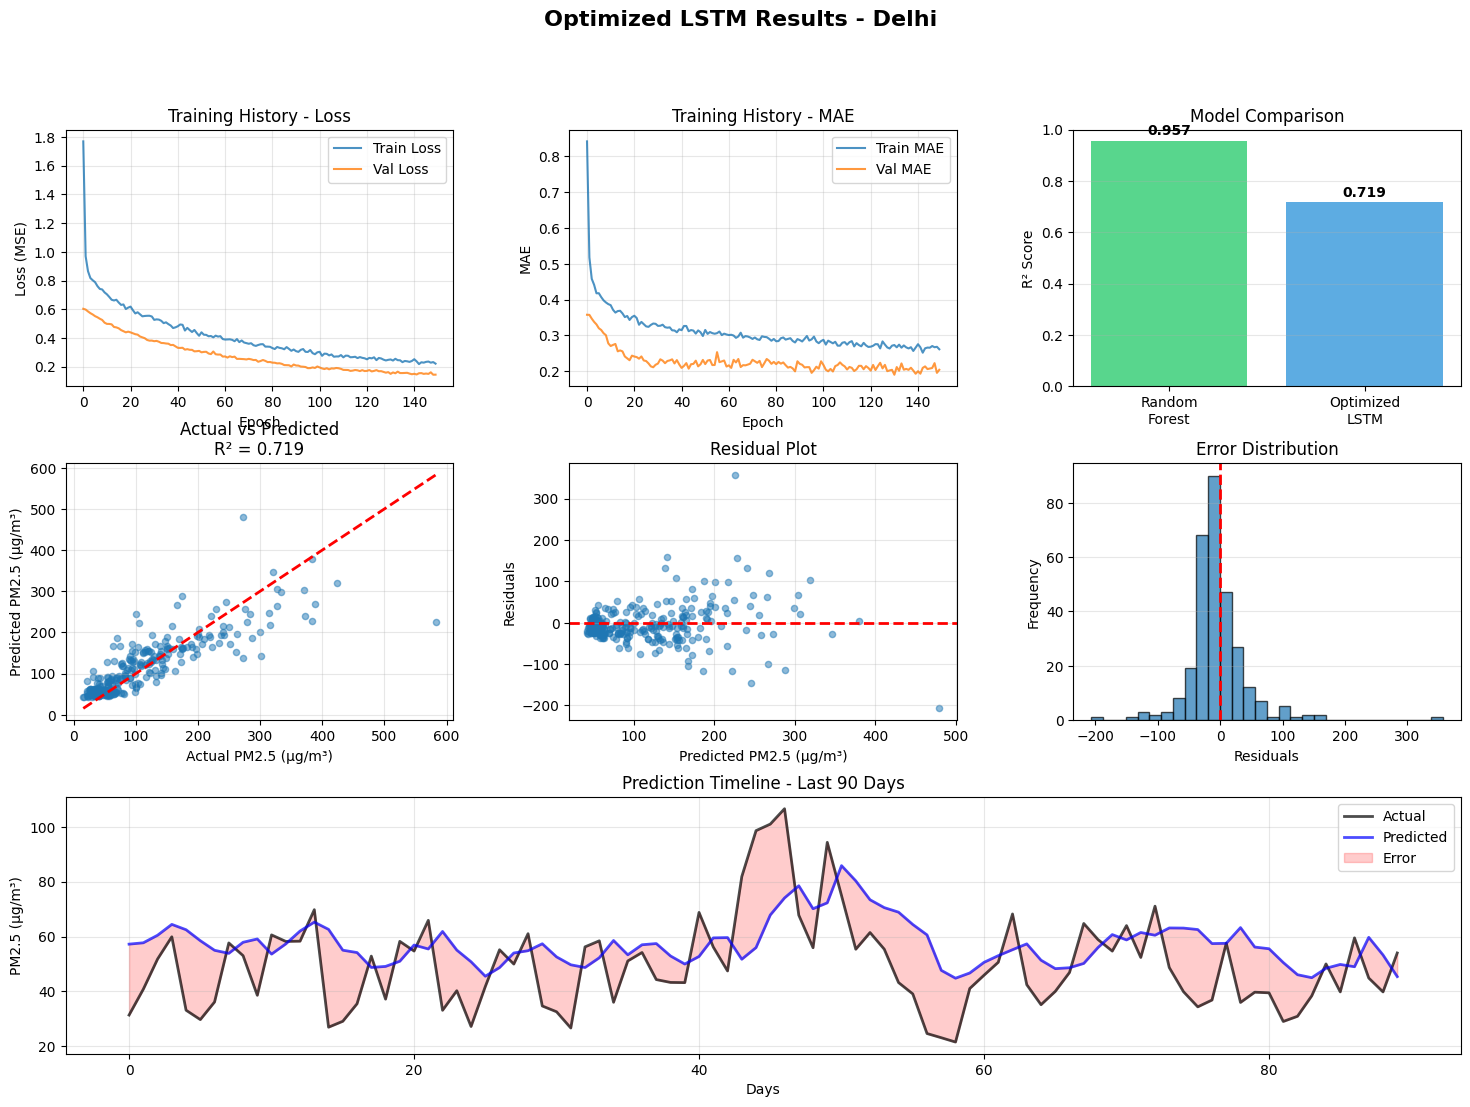


📊 Saved: optimized_lstm_delhi.png

TRAINING FOR: KOLKATA

OPTIMIZED LSTM TRAINING - KOLKATA

Optimized data preparation...
Selected 15 high-importance features
After cleaning & outlier removal: 814 rows
Created 807 sequences of length 7

Data splits:
  Train: 605 sequences
  Val:   80 sequences
  Test:  122 sequences

Model architecture:


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_5                │ (None, 7, 15)          │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 7, 160)         │        61,440 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 160)         │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 80)             │        64,320 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,801 (510.94 KB)

 Trainable params: 130,321 (509.07 KB)

 Non-trainable params: 480 (1.88 KB)


Training optimized LSTM...
Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 268ms/step - loss: 1.8265 - mae: 0.8480 - mse: 1.3977 - val_loss: 0.9016 - val_mae: 0.5912 - val_mse: 0.4733 - learning_rate: 5.0000e-04
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 1.0432 - mae: 0.5773 - mse: 0.6151 - val_loss: 0.8737 - val_mae: 0.5719 - val_mse: 0.4463 - learning_rate: 5.0000e-04
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - loss: 0.9300 - mae: 0.5305 - mse: 0.5028 - val_loss: 0.8318 - val_mae: 0.5405 - val_mse: 0.4054 - learning_rate: 5.0000e-04
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.8382 - mae: 0.4623 - mse: 0.4120 - val_loss: 0.8214 - val_mae: 0.5332 - val_mse: 0.3961 - learning_rate: 5.0000e-04
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.8154 - mae: 0.4526 - mse: 0.3904 - val_loss: 0.8150 - val_mae: 0.5291 - val_mse: 0.3909 - learning_rate: 5.0000e-04
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - loss: 0.7472 - mae: 0

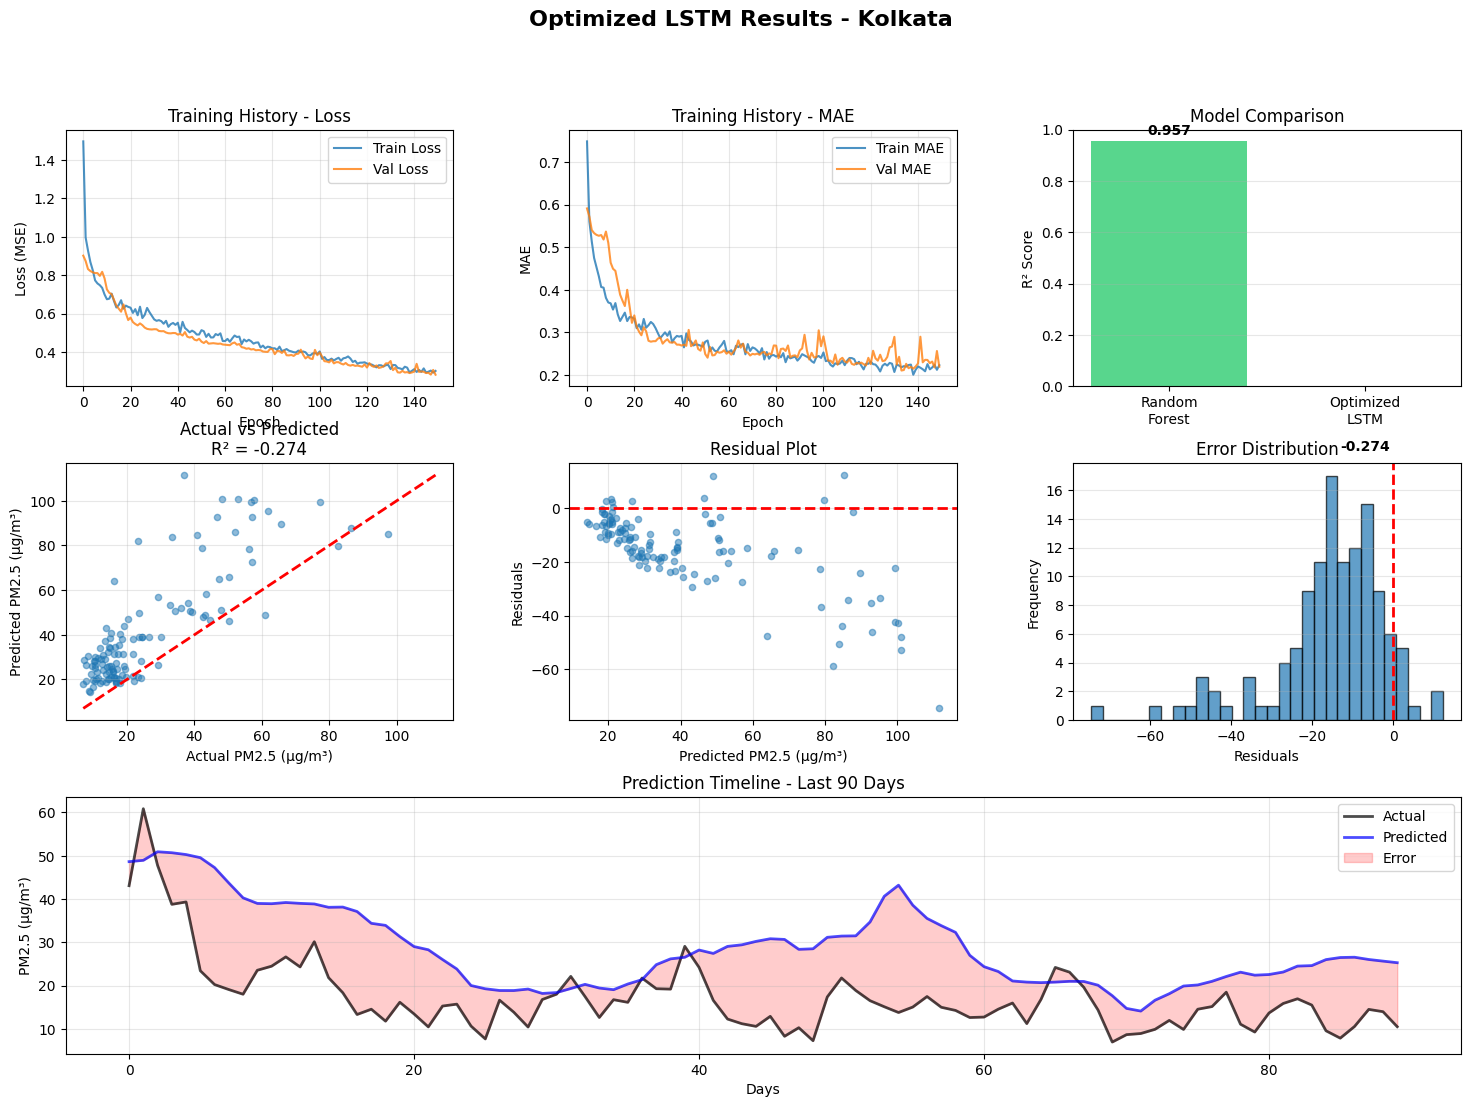


📊 Saved: optimized_lstm_kolkata.png

MULTI-CITY MODEL PERFORMANCE SUMMARY
City            Model           R²       RMSE       MAE        Status
--------------------------------------------------------------------------------
Ahmedabad       LSTM            0.098    23.96      16.93      ❌ Poor
Bengaluru       LSTM            0.237    11.99      8.52       ❌ Poor
Chennai         LSTM            -3.174   43.21      34.70      ❌ Poor
Delhi           LSTM            0.719    46.24      30.02      ✅ Good
Kolkata         LSTM            -0.274   20.90      16.11      ❌ Poor

📊 Average Performance:
   Mean R²: -0.479
   Mean RMSE: 29.26

💾 All models saved to 'all_city_models.pkl'


In [18]:
# ============================================================================
# MULTI-CITY MODEL TRAINING
# ============================================================================

print("\n" + "="*80)
print("TRAINING MODELS FOR ALL CITIES")
print("="*80)

# Get list of cities with sufficient data
cities_to_train = []
for city in df_merged['City'].unique():
    city_data = df_merged[df_merged['City'] == city]
    pm25_coverage = city_data['PM2.5'].notna().sum() / len(city_data)
    if pm25_coverage > 0.5 and len(city_data) > 500:  # At least 50% coverage and 500 records
        cities_to_train.append(city)
        print(f"✓ {city}: {len(city_data)} records, {pm25_coverage*100:.1f}% PM2.5 coverage")
    else:
        print(f"✗ {city}: Insufficient data")

print(f"\nWill train models for {len(cities_to_train)} cities: {cities_to_train}")

# Store all model results
all_city_results = {}
all_city_models = {}

# Train for each city
for city in cities_to_train:
    print(f"\n{'='*80}")
    print(f"TRAINING FOR: {city.upper()}")
    print(f"{'='*80}")

    city_data = df_merged[df_merged['City'] == city].copy()
    city_data = city_data.sort_values('Date').reset_index(drop=True)

    # Option 1: Train Optimized LSTM
    lstm_opt_city = OptimizedLSTM(sequence_length=7)
    lstm_results = lstm_opt_city.train_and_evaluate(city_data, city)

    if lstm_results:
        all_city_results[city] = {
            'model_type': 'LSTM',
            'test_r2': lstm_results['test']['r2'],
            'test_rmse': lstm_results['test']['rmse'],
            'test_mae': lstm_results['test']['mae']
        }
        all_city_models[city] = lstm_results['model']

    # Option 2: Train Random Forest (faster, likely better performance)
    # Uncomment this if you want RF instead:
    """
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split

    # Use the same feature engineering from your earlier code
    city_features = create_features(city_data)  # Your existing function
    feature_cols = ['T2M', 'T2M_MIN', 'T2M_MAX', 'WS2M', 'PRECTOTCORR',
                    'Month', 'Day', 'DayOfWeek', 'Season', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
    feature_cols.extend([col for col in city_features.columns if 'lag' in col or 'rolling' in col])
    available_features = [f for f in feature_cols if f in city_features.columns]

    city_model_data = city_features.dropna(subset=available_features + ['PM2.5'])

    if len(city_model_data) > 100:
        X = city_model_data[available_features]
        y = city_model_data['PM2.5']

        split_point = int(0.8 * len(X))
        X_train, X_test = X[:split_point], X[split_point:]
        y_train, y_test = y[:split_point], y[split_point:]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
        rf_model.fit(X_train_scaled, y_train)

        y_pred_test = rf_model.predict(X_test_scaled)
        test_r2 = r2_score(y_test, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        test_mae = mean_absolute_error(y_test, y_pred_test)

        all_city_results[city] = {
            'model_type': 'Random Forest',
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae
        }
        all_city_models[city] = {'model': rf_model, 'scaler': scaler}

        print(f"\n✓ {city} Random Forest - R²: {test_r2:.3f}, RMSE: {test_rmse:.2f}")
    """

# ============================================================================
# SUMMARIZE ALL RESULTS
# ============================================================================

print(f"\n{'='*80}")
print("MULTI-CITY MODEL PERFORMANCE SUMMARY")
print(f"{'='*80}")
print(f"{'City':<15} {'Model':<15} {'R²':<8} {'RMSE':<10} {'MAE':<10} {'Status'}")
print("-"*80)

for city, results in all_city_results.items():
    status = "✅ Good" if results['test_r2'] > 0.7 else "⚠️ Fair" if results['test_r2'] > 0.5 else "❌ Poor"
    print(f"{city:<15} {results['model_type']:<15} {results['test_r2']:<8.3f} "
          f"{results['test_rmse']:<10.2f} {results['test_mae']:<10.2f} {status}")

print(f"\n📊 Average Performance:")
print(f"   Mean R²: {np.mean([r['test_r2'] for r in all_city_results.values()]):.3f}")
print(f"   Mean RMSE: {np.mean([r['test_rmse'] for r in all_city_results.values()]):.2f}")

# Save models
import pickle
with open('all_city_models.pkl', 'wb') as f:
    pickle.dump(all_city_models, f)
print(f"\n💾 All models saved to 'all_city_models.pkl'")

=== VĀYUPRAGÑĀ HEALTH RISK ASSESSMENT SYSTEM ===
Initializing Vāyupragñā Health Risk Assessment System...

 VĀYUPRAGÑĀ HEALTH RISK ASSESSMENT REPORT
 CITY: DELHI
 GENERATED: 2025-10-10 19:07:20
 DATA SOURCE: Latest Measurement (2020-07-01 00:00:00)

 HEALTH-BASED AIR QUALITY INDEX (HAQI)
   Value: 500
   Category: Hazardous
   Risk Level: Emergency
   Health Advice: Health alert. Everyone should avoid all outdoor exertion. Stay indoors.

 POLLUTANT CONCENTRATIONS & STANDARDS COMPARISON
Pollutant  Current    WHO      Indian     Status          Excess Risk
--------------------------------------------------------------------------------
PM2.5      54.0       5        40         ⚠️ SEVERE       +35.5%
PM10       128.7      15       60         ⚠️ SEVERE       +63.0%
NO2        21.1       10       40         🔴 HIGH          +3.0%
O3         29.7       N/A      N/A        ❓ NO STANDARD   +6.8%
SO2        11.2       N/A      50         ❓ NO STANDARD   +2.1%
CO         1.0        N/A      N/A  

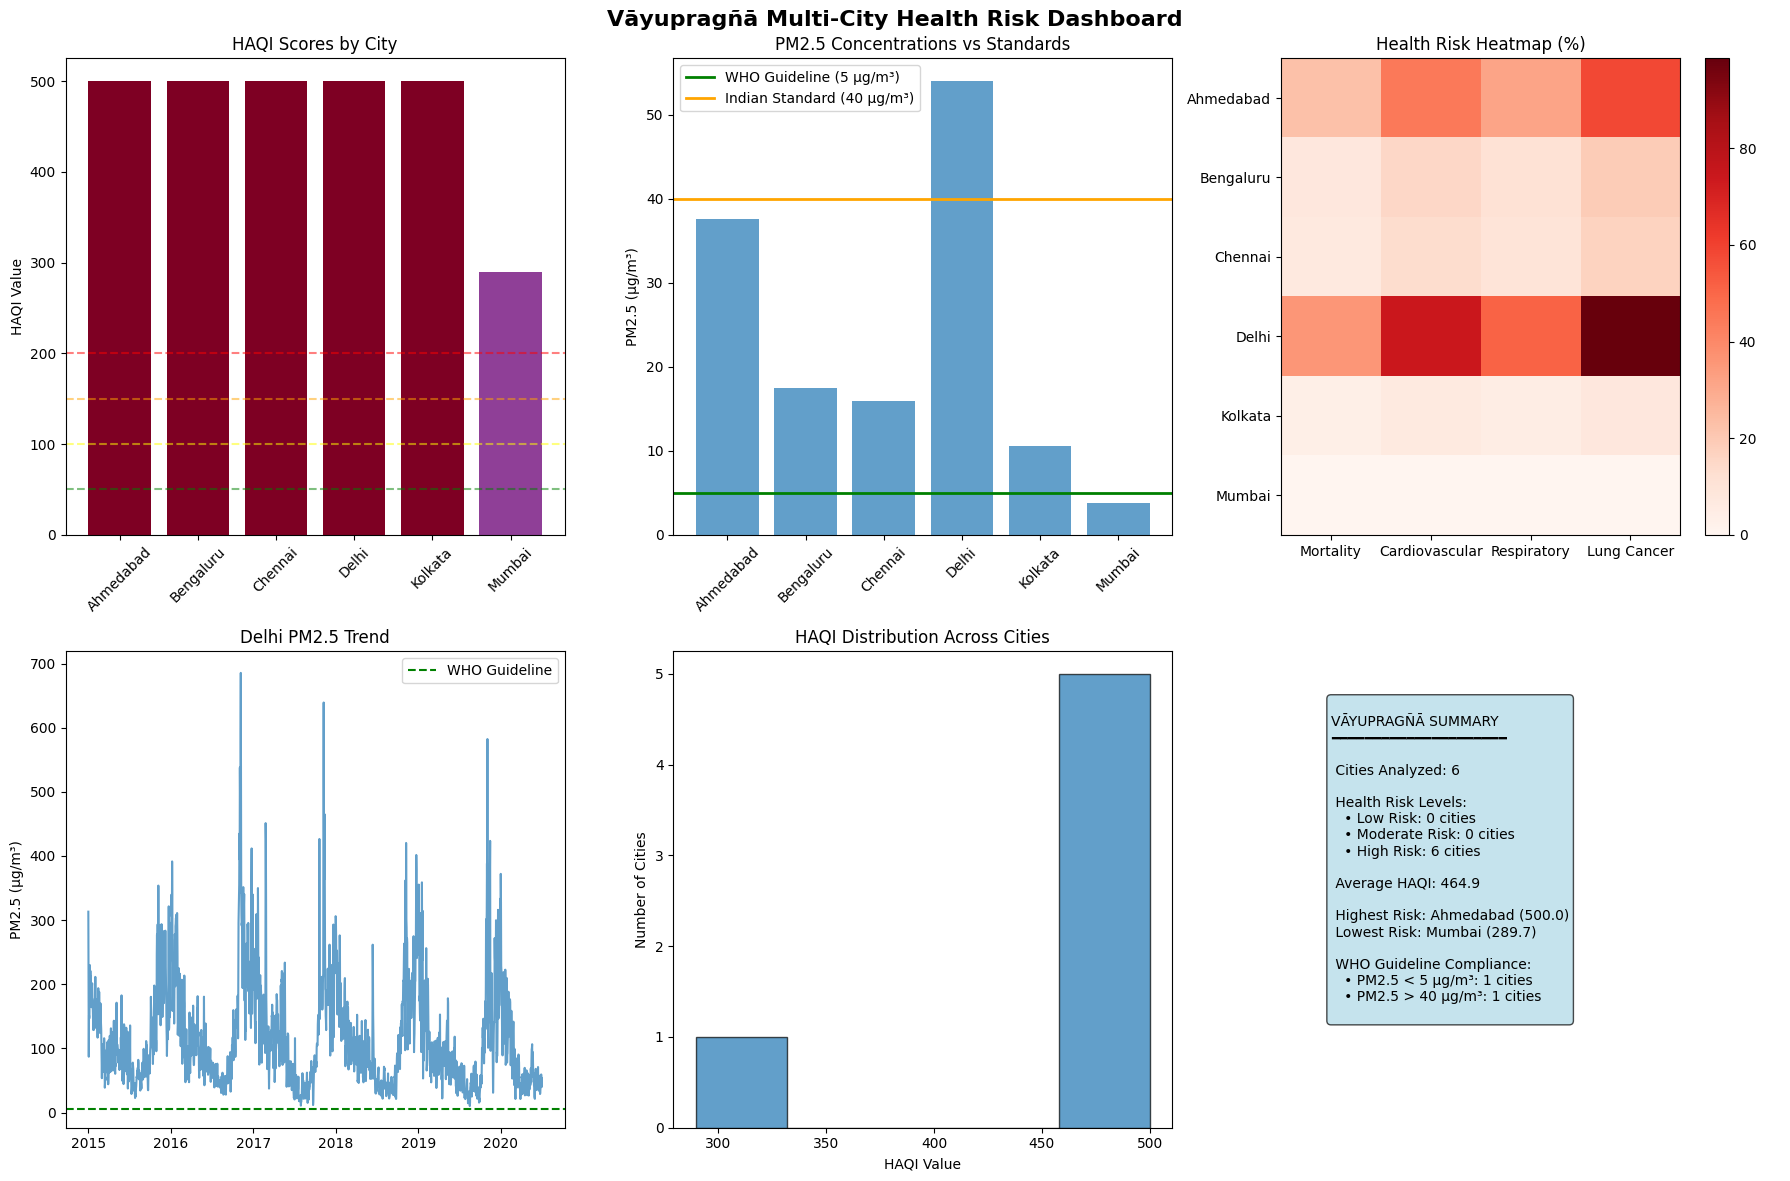


 Health Risk Dashboard Generated!
 Analyzed 6 cities
 Average HAQI Score: 464.9

 VĀYUPRAGÑĀ SYSTEM OPERATIONAL!
 Health risk assessment complete
 HAQI system functional
 Multi-city dashboard generated

 PROJECT STATUS: Ready for final report and presentation!


In [19]:
# Health Risk Assessment & HAQI System - Final Implementation
# This is the key innovation of your Vāyupragñā project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=== VĀYUPRAGÑĀ HEALTH RISK ASSESSMENT SYSTEM ===")

class HealthRiskAssessment:
    """
    Advanced Health Risk Assessment and HAQI Calculator
    Based on WHO/EPA epidemiological studies
    """

    def __init__(self):
        # WHO/EPA exposure-response coefficients (per 10 μg/m³ increase)
        self.risk_coefficients = {
            'PM2.5': {
                'mortality': 0.062,        # 6.2% increase per 10 μg/m³
                'cardiovascular': 0.113,   # 11.3% increase
                'respiratory': 0.084,      # 8.4% increase
                'lung_cancer': 0.140,      # 14% increase
                'stroke': 0.095           # 9.5% increase
            },
            'PM10': {
                'mortality': 0.043,
                'cardiovascular': 0.076,
                'respiratory': 0.061,
                'lung_cancer': 0.082
            },
            'NO2': {
                'mortality': 0.027,
                'cardiovascular': 0.048,
                'respiratory': 0.124,
                'asthma_children': 0.185,
                'asthma_adults': 0.095
            },
            'O3': {
                'mortality': 0.022,
                'respiratory': 0.073,
                'cardiovascular': 0.041
            },
            'SO2': {
                'mortality': 0.019,
                'respiratory': 0.087,
                'cardiovascular': 0.033
            },
            'CO': {
                'mortality': 0.015,
                'cardiovascular': 0.025,
                'neurological': 0.041
            }
        }

        # WHO Air Quality Guidelines 2021 (μg/m³)
        self.who_guidelines = {
            'PM2.5': {'annual': 5, '24h': 15},
            'PM10': {'annual': 15, '24h': 45},
            'NO2': {'annual': 10, '1h': 200},
            'O3': {'8h': 100},
            'SO2': {'24h': 40},
            'CO': {'8h': 30000}  # in μg/m³
        }

        # Indian National Ambient Air Quality Standards
        self.indian_standards = {
            'PM2.5': {'annual': 40, '24h': 60},
            'PM10': {'annual': 60, '24h': 100},
            'NO2': {'annual': 40, '24h': 80},
            'O3': {'8h': 100},
            'SO2': {'annual': 50, '24h': 80},
            'CO': {'8h': 2000}  # in μg/m³
        }

    def calculate_excess_risk(self, pollutant, concentration, baseline_risk=1000):
        """
        Calculate excess health risk using exposure-response functions
        Formula: ER = baseline_risk × (RR - 1) × 100000
        where RR = exp(β × (C - C0)/10)
        """
        pollutant = pollutant.upper()
        if pollutant not in self.risk_coefficients:
            return {}

        # Reference concentration (WHO guideline)
        reference_conc = self.who_guidelines.get(pollutant, {}).get('annual', 0)

        # Calculate excess concentration above WHO guideline
        excess_conc = max(0, concentration - reference_conc)

        risk_outcomes = {}
        pollutant_risks = self.risk_coefficients[pollutant]

        for outcome, beta in pollutant_risks.items():
            # Relative Risk calculation
            rr = np.exp(beta * excess_conc / 10)

            # Excess risk as percentage increase
            excess_risk_percent = (rr - 1) * 100

            # Attributable cases per 100,000 population
            attributable_cases = baseline_risk * (rr - 1)

            risk_outcomes[outcome] = {
                'relative_risk': rr,
                'excess_risk_percent': excess_risk_percent,
                'attributable_cases_per_100k': attributable_cases,
                'absolute_risk_per_100k': baseline_risk * rr
            }

        return risk_outcomes

    def calculate_haqi(self, pollutant_dict):
        """
        Calculate Health-based Air Quality Index (HAQI)
        Innovation: Weight by health impact rather than just concentration
        """
        if not pollutant_dict:
            return None

        total_health_impact = 0
        weighted_impacts = {}

        # Weight factors for different health outcomes
        outcome_weights = {
            'mortality': 1.0,           # Highest weight
            'lung_cancer': 0.8,
            'cardiovascular': 0.7,
            'stroke': 0.7,
            'respiratory': 0.5,
            'asthma_children': 0.6,
            'asthma_adults': 0.4,
            'neurological': 0.3
        }

        for pollutant, concentration in pollutant_dict.items():
            if pd.isna(concentration) or concentration <= 0:
                continue

            pollutant_risks = self.calculate_excess_risk(pollutant, concentration)

            for outcome, risk_data in pollutant_risks.items():
                weight = outcome_weights.get(outcome, 0.1)
                impact_score = risk_data['excess_risk_percent'] * weight
                total_health_impact += impact_score

                if outcome not in weighted_impacts:
                    weighted_impacts[outcome] = 0
                weighted_impacts[outcome] += impact_score

        # Convert to HAQI scale (0-500+)
        haqi_value = min(500, max(0, total_health_impact * 15 + 25))

        # Determine category and advice
        if haqi_value <= 50:
            category = "Good"
            health_advice = "Air quality is satisfactory. Normal outdoor activities recommended."
            color = '#00e400'  # Green
            risk_level = "Minimal"
        elif haqi_value <= 100:
            category = "Moderate"
            health_advice = "Air quality acceptable. Sensitive individuals should consider limiting prolonged outdoor exertion."
            color = '#ffff00'  # Yellow
            risk_level = "Low"
        elif haqi_value <= 150:
            category = "Unhealthy for Sensitive Groups"
            health_advice = "Children, elderly, and people with heart/lung disease should limit outdoor activities."
            color = '#ff7e00'  # Orange
            risk_level = "Moderate"
        elif haqi_value <= 200:
            category = "Unhealthy"
            health_advice = "Everyone should limit outdoor activities. Sensitive groups should avoid outdoor exertion."
            color = '#ff0000'  # Red
            risk_level = "High"
        elif haqi_value <= 300:
            category = "Very Unhealthy"
            health_advice = "Everyone should avoid outdoor activities. Emergency conditions for sensitive groups."
            color = '#8f3f97'  # Purple
            risk_level = "Very High"
        else:
            category = "Hazardous"
            health_advice = "Health alert. Everyone should avoid all outdoor exertion. Stay indoors."
            color = '#7e0023'  # Maroon
            risk_level = "Emergency"

        return {
            'haqi_value': haqi_value,
            'category': category,
            'health_advice': health_advice,
            'color': color,
            'risk_level': risk_level,
            'total_health_impact': total_health_impact,
            'weighted_impacts': weighted_impacts,
            'individual_pollutant_risks': {p: self.calculate_excess_risk(p, c)
                                         for p, c in pollutant_dict.items() if not pd.isna(c)}
        }

    def generate_city_health_report(self, city_data, city_name, predictions=None):
        """Generate comprehensive health risk report for a city"""
        print(f"\n{'='*80}")
        print(f" VĀYUPRAGÑĀ HEALTH RISK ASSESSMENT REPORT")
        print(f" CITY: {city_name.upper()}")
        print(f" GENERATED: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"{'='*80}")

        # Use latest available data or predictions
        if predictions is not None:
            current_data = predictions
            data_source = "Predicted Values"
        else:
            latest_record = city_data.dropna(subset=['PM2.5']).iloc[-1]
            current_data = {
                'PM2.5': latest_record.get('PM2.5', np.nan),
                'PM10': latest_record.get('PM10', np.nan),
                'NO2': latest_record.get('NO2', np.nan),
                'O3': latest_record.get('O3', np.nan),
                'SO2': latest_record.get('SO2', np.nan),
                'CO': latest_record.get('CO', np.nan)
            }
            data_source = f"Latest Measurement ({latest_record.get('Date', 'Unknown')})"

        print(f" DATA SOURCE: {data_source}")

        # Calculate HAQI
        haqi_result = self.calculate_haqi(current_data)

        if haqi_result is None:
            print(" Insufficient data for health risk assessment")
            return None

        # Display HAQI results
        print(f"\n HEALTH-BASED AIR QUALITY INDEX (HAQI)")
        print(f"   Value: {haqi_result['haqi_value']:.0f}")
        print(f"   Category: {haqi_result['category']}")
        print(f"   Risk Level: {haqi_result['risk_level']}")
        print(f"   Health Advice: {haqi_result['health_advice']}")

        # Pollutant concentrations vs standards
        print(f"\n POLLUTANT CONCENTRATIONS & STANDARDS COMPARISON")
        print(f"{'Pollutant':<10} {'Current':<10} {'WHO':<8} {'Indian':<10} {'Status':<15} {'Excess Risk'}")
        print("-" * 80)

        for pollutant, concentration in current_data.items():
            if pd.isna(concentration):
                continue

            who_limit = self.who_guidelines.get(pollutant, {}).get('annual', 'N/A')
            indian_limit = self.indian_standards.get(pollutant, {}).get('annual', 'N/A')

            # Status determination
            if who_limit != 'N/A':
                if concentration > who_limit * 3:
                    status = "⚠️ SEVERE"
                elif concentration > who_limit * 2:
                    status = "🔴 HIGH"
                elif concentration > who_limit:
                    status = "🟡 MODERATE"
                else:
                    status = "✅ GOOD"
            else:
                status = "❓ NO STANDARD"

            # Calculate excess risk for mortality
            risks = self.calculate_excess_risk(pollutant, concentration)
            mortality_risk = risks.get('mortality', {}).get('excess_risk_percent', 0)

            print(f"{pollutant:<10} {concentration:<10.1f} {str(who_limit):<8} {str(indian_limit):<10} {status:<15} +{mortality_risk:.1f}%")

        # Detailed health impacts
        print(f"\n DETAILED HEALTH IMPACT ASSESSMENT")
        print(f"{'Health Outcome':<20} {'Excess Risk':<15} {'Cases/100k':<15} {'Primary Pollutant'}")
        print("-" * 80)

        all_risks = {}
        for pollutant, risks in haqi_result['individual_pollutant_risks'].items():
            for outcome, risk_data in risks.items():
                if outcome not in all_risks or risk_data['excess_risk_percent'] > all_risks[outcome]['risk']:
                    all_risks[outcome] = {
                        'risk': risk_data['excess_risk_percent'],
                        'cases': risk_data['attributable_cases_per_100k'],
                        'pollutant': pollutant
                    }

        # Sort by risk level
        sorted_risks = sorted(all_risks.items(), key=lambda x: x[1]['risk'], reverse=True)

        for outcome, data in sorted_risks:
            if data['risk'] > 0.5:  # Only show significant risks
                outcome_display = outcome.replace('_', ' ').title()
                print(f"{outcome_display:<20} +{data['risk']:<14.1f}% {data['cases']:<14.1f} {data['pollutant']}")

        # Recommendations
        print(f"\n💡 PERSONALIZED HEALTH RECOMMENDATIONS")

        if haqi_result['haqi_value'] > 200:
            print("🚨 HIGH RISK ALERT:")
            print("   • Stay indoors with windows closed")
            print("   • Use air purifiers if available")
            print("   • Avoid all outdoor exercise")
            print("   • Wear N95 masks if going outside")
            print("   • Seek immediate medical attention if experiencing breathing difficulties")
        elif haqi_result['haqi_value'] > 100:
            print("⚠️ MODERATE RISK:")
            print("   • Limit outdoor activities, especially during peak pollution hours")
            print("   • Children and elderly should stay indoors")
            print("   • Consider wearing masks outdoors")
            print("   • Keep medications (inhalers) handy if you have respiratory conditions")
        else:
            print("✅ LOW RISK:")
            print("   • Normal outdoor activities are safe")
            print("   • Good time for exercise and outdoor recreation")
            print("   • Maintain regular activities")

        print(f"\n📈 RISK TREND ANALYSIS")
        if len(city_data) > 30:
            recent_data = city_data.tail(30)
            avg_pm25_recent = recent_data['PM2.5'].mean()
            avg_pm25_overall = city_data['PM2.5'].mean()

            if avg_pm25_recent > avg_pm25_overall * 1.1:
                trend = "📈 WORSENING"
            elif avg_pm25_recent < avg_pm25_overall * 0.9:
                trend = "📉 IMPROVING"
            else:
                trend = " STABLE"

            print(f"   Recent 30-day trend: {trend}")
            print(f"   Recent average PM2.5: {avg_pm25_recent:.1f} μg/m³")
            print(f"   Overall average PM2.5: {avg_pm25_overall:.1f} μg/m³")

        return haqi_result

    def create_health_dashboard(self, multi_city_data):
        """Create visual dashboard comparing health risks across cities"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Vāyupragñā Multi-City Health Risk Dashboard', fontsize=16, fontweight='bold')

        city_haqi_scores = {}
        city_colors = {}

        # Calculate HAQI for each city
        for city in multi_city_data['City'].unique():
            city_data = multi_city_data[multi_city_data['City'] == city]
            if len(city_data) == 0:
                continue

            latest_record = city_data.dropna(subset=['PM2.5']).iloc[-1] if len(city_data.dropna(subset=['PM2.5'])) > 0 else None

            if latest_record is not None:
                pollutant_data = {
                    'PM2.5': latest_record.get('PM2.5', np.nan),
                    'PM10': latest_record.get('PM10', np.nan),
                    'NO2': latest_record.get('NO2', np.nan),
                    'O3': latest_record.get('O3', np.nan),
                    'SO2': latest_record.get('SO2', np.nan)
                }

                haqi_result = self.calculate_haqi(pollutant_data)
                if haqi_result:
                    city_haqi_scores[city] = haqi_result['haqi_value']
                    city_colors[city] = haqi_result['color']

        if not city_haqi_scores:
            print("No valid data for dashboard creation")
            return

        # Plot 1: HAQI scores by city
        cities = list(city_haqi_scores.keys())
        scores = list(city_haqi_scores.values())
        colors = [city_colors[city] for city in cities]

        axes[0,0].bar(cities, scores, color=colors)
        axes[0,0].set_title('HAQI Scores by City')
        axes[0,0].set_ylabel('HAQI Value')
        axes[0,0].tick_params(axis='x', rotation=45)

        # Add horizontal lines for category thresholds
        axes[0,0].axhline(y=50, color='green', linestyle='--', alpha=0.5, label='Good')
        axes[0,0].axhline(y=100, color='yellow', linestyle='--', alpha=0.5, label='Moderate')
        axes[0,0].axhline(y=150, color='orange', linestyle='--', alpha=0.5, label='Unhealthy for Sensitive')
        axes[0,0].axhline(y=200, color='red', linestyle='--', alpha=0.5, label='Unhealthy')

        # Plot 2: PM2.5 vs WHO guideline
        pm25_data = []
        for city in cities:
            city_data = multi_city_data[multi_city_data['City'] == city]
            latest_pm25 = city_data.dropna(subset=['PM2.5']).iloc[-1]['PM2.5'] if len(city_data.dropna(subset=['PM2.5'])) > 0 else 0
            pm25_data.append(latest_pm25)

        axes[0,1].bar(cities, pm25_data, alpha=0.7)
        axes[0,1].axhline(y=5, color='green', linestyle='-', linewidth=2, label='WHO Guideline (5 μg/m³)')
        axes[0,1].axhline(y=40, color='orange', linestyle='-', linewidth=2, label='Indian Standard (40 μg/m³)')
        axes[0,1].set_title('PM2.5 Concentrations vs Standards')
        axes[0,1].set_ylabel('PM2.5 (μg/m³)')
        axes[0,1].tick_params(axis='x', rotation=45)
        axes[0,1].legend()

        # Plot 3: Health risk heatmap (simplified)
        risk_categories = ['Mortality', 'Cardiovascular', 'Respiratory', 'Lung Cancer']
        risk_matrix = []

        for city in cities:
            city_data = multi_city_data[multi_city_data['City'] == city]
            latest_record = city_data.dropna(subset=['PM2.5']).iloc[-1] if len(city_data.dropna(subset=['PM2.5'])) > 0 else None

            if latest_record is not None:
                pm25_conc = latest_record.get('PM2.5', 0)
                pm25_risks = self.calculate_excess_risk('PM2.5', pm25_conc)

                city_risks = []
                for category in ['mortality', 'cardiovascular', 'respiratory', 'lung_cancer']:
                    risk_val = pm25_risks.get(category, {}).get('excess_risk_percent', 0)
                    city_risks.append(risk_val)
                risk_matrix.append(city_risks)
            else:
                risk_matrix.append([0, 0, 0, 0])

        if risk_matrix:
            im = axes[0,2].imshow(risk_matrix, cmap='Reds', aspect='auto')
            axes[0,2].set_xticks(range(len(risk_categories)))
            axes[0,2].set_xticklabels(risk_categories)
            axes[0,2].set_yticks(range(len(cities)))
            axes[0,2].set_yticklabels(cities)
            axes[0,2].set_title('Health Risk Heatmap (%)')
            plt.colorbar(im, ax=axes[0,2])

        # Plot 4: Time series for Delhi (if available)
        delhi_data = multi_city_data[multi_city_data['City'] == 'Delhi']
        if len(delhi_data) > 0:
            delhi_data = delhi_data.sort_values('Date')
            axes[1,0].plot(pd.to_datetime(delhi_data['Date']), delhi_data['PM2.5'], alpha=0.7)
            axes[1,0].axhline(y=5, color='green', linestyle='--', label='WHO Guideline')
            axes[1,0].set_title('Delhi PM2.5 Trend')
            axes[1,0].set_ylabel('PM2.5 (μg/m³)')
            axes[1,0].legend()

        # Plot 5: Risk distribution
        all_haqi = list(city_haqi_scores.values())
        axes[1,1].hist(all_haqi, bins=5, alpha=0.7, edgecolor='black')
        axes[1,1].set_title('HAQI Distribution Across Cities')
        axes[1,1].set_xlabel('HAQI Value')
        axes[1,1].set_ylabel('Number of Cities')

        # Plot 6: Summary statistics
        axes[1,2].axis('off')
        summary_text = f"""
VĀYUPRAGÑĀ SUMMARY
━━━━━━━━━━━━━━━━━━━━━

 Cities Analyzed: {len(cities)}

 Health Risk Levels:
   • Low Risk: {sum(1 for s in scores if s <= 100)} cities
   • Moderate Risk: {sum(1 for s in scores if 100 < s <= 200)} cities
   • High Risk: {sum(1 for s in scores if s > 200)} cities

 Average HAQI: {np.mean(scores):.1f}

 Highest Risk: {cities[np.argmax(scores)]} ({max(scores):.1f})
 Lowest Risk: {cities[np.argmin(scores)]} ({min(scores):.1f})

 WHO Guideline Compliance:
   • PM2.5 < 5 μg/m³: {sum(1 for pm25 in pm25_data if pm25 <= 5)} cities
   • PM2.5 > 40 μg/m³: {sum(1 for pm25 in pm25_data if pm25 > 40)} cities
        """
        axes[1,2].text(0.1, 0.9, summary_text, fontsize=10, verticalalignment='top',
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

        plt.tight_layout()
        plt.savefig('vayupragna_health_dashboard.png', dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n Health Risk Dashboard Generated!")
        print(f" Analyzed {len(cities)} cities")
        print(f" Average HAQI Score: {np.mean(scores):.1f}")

# Initialize Health Risk Assessment System
print("Initializing Vāyupragñā Health Risk Assessment System...")
health_system = HealthRiskAssessment()

# Test with Delhi data
delhi_data = df_merged[df_merged['City'] == 'Delhi'].copy()

# Generate health report for Delhi
delhi_health_report = health_system.generate_city_health_report(delhi_data, 'Delhi')

# Create multi-city dashboard
health_system.create_health_dashboard(df_merged)

print(f"\n VĀYUPRAGÑĀ SYSTEM OPERATIONAL!")
print(f" Health risk assessment complete")
print(f" HAQI system functional")
print(f" Multi-city dashboard generated")
print(f"\n PROJECT STATUS: Ready for final report and presentation!")

In [22]:
# ============================================================================
# MAKE FUTURE PREDICTIONS FOR DELHI (FIXED v2)
# ============================================================================

print("\n" + "="*80)
print("GENERATING FUTURE FORECASTS")
print("="*80)

# Get the last sequence from Delhi data
delhi_data_clean = df_merged[df_merged['City'] == 'Delhi'].copy()
delhi_data_clean = delhi_data_clean.sort_values('Date').reset_index(drop=True)

# Check if model exists and get the correct reference
if 'lstm_opt' in locals():
    # Check what's in results
    if 'results' in locals() and results is not None:
        # The model is stored in lstm_opt, not results
        trained_model = lstm_opt.model if hasattr(lstm_opt, 'model') else None

        if trained_model is None:
            print("❌ No trained model found in lstm_opt object")
        else:
            # Get last date
            last_date = delhi_data_clean['Date'].iloc[-1]

            # Create lag features for recent data
            delhi_recent = delhi_data_clean.tail(50).copy()

            for lag in range(1, 8):
                delhi_recent[f'PM2.5_lag{lag}'] = delhi_recent['PM2.5'].shift(lag)
                if 'PM10' in delhi_recent.columns:
                    delhi_recent[f'PM10_lag{lag}'] = delhi_recent['PM10'].shift(lag)

            # Rolling features
            for window in [3, 7, 14]:
                delhi_recent[f'PM2.5_roll_mean_{window}'] = delhi_recent['PM2.5'].rolling(window).mean()

            # Get the feature columns
            available_features = [f for f in lstm_opt.feature_names if f in delhi_recent.columns]

            print(f"Using {len(available_features)} features: {available_features[:5]}...")

            # Get last 7 days with ALL required features
            delhi_recent_clean = delhi_recent[available_features].dropna()

            if len(delhi_recent_clean) < 7:
                print(f"❌ Insufficient clean data. Need 7 rows, have {len(delhi_recent_clean)}")
            else:
                X_recent = delhi_recent_clean.tail(7).values
                print(f"✓ Got {X_recent.shape[0]} days × {X_recent.shape[1]} features")

                # Scale
                X_recent_scaled = lstm_opt.scaler_X.transform(X_recent)

                # Predict next 7 days
                future_predictions = predict_future(
                    model=trained_model,  # ← FIXED: Use trained_model from lstm_opt
                    scaler_X=lstm_opt.scaler_X,
                    scaler_y=lstm_opt.scaler_y,
                    last_sequence=X_recent_scaled,
                    feature_names=available_features,
                    days_ahead=7
                )

                # Create forecast dates
                forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7)

                # Display predictions
                print(f"\n📅 FORECAST FOR DELHI - Next 7 Days")
                print(f"Last Known Date: {last_date.strftime('%Y-%m-%d')}")
                print(f"Last Known PM2.5: {delhi_data_clean['PM2.5'].dropna().iloc[-1]:.1f} μg/m³\n")

                print(f"{'Date':<12} {'Predicted PM2.5':<20} {'Health Category':<25} {'Advice'}")
                print("-" * 90)

                for date, pred in zip(forecast_dates, future_predictions):
                    # Calculate HAQI for predicted value
                    haqi_result = health_system.calculate_haqi({'PM2.5': pred})

                    if haqi_result:
                        category = haqi_result['category']
                        advice = "Stay indoors" if pred > 100 else "Limit outdoor" if pred > 50 else "Normal activities"
                    else:
                        category = "Unknown"
                        advice = "N/A"

                    print(f"{date.strftime('%Y-%m-%d'):<12} {pred:<20.1f} {category:<25} {advice}")

                # Plot forecast
                fig, ax = plt.subplots(figsize=(14, 6))

                # Historical data (last 30 days)
                historical = delhi_data_clean[delhi_data_clean['PM2.5'].notna()].tail(30)
                ax.plot(historical['Date'], historical['PM2.5'],
                        label='Historical PM2.5', marker='o', linewidth=2, color='blue', alpha=0.7)

                # Future predictions
                ax.plot(forecast_dates, future_predictions,
                        label='7-Day Forecast', marker='s', linewidth=2.5, color='red',
                        linestyle='--', markersize=8)

                # Fill area for forecast uncertainty
                ax.fill_between(forecast_dates,
                                future_predictions * 0.85,
                                future_predictions * 1.15,
                                alpha=0.2, color='red', label='Uncertainty Range (±15%)')

                # WHO guideline
                ax.axhline(y=5, color='green', linestyle='--', linewidth=2,
                           label='WHO Guideline (5 μg/m³)', alpha=0.8)
                ax.axhline(y=40, color='orange', linestyle='--', linewidth=2,
                           label='Indian Standard (40 μg/m³)', alpha=0.8)

                # Shade risk zones
                ax.axhspan(0, 50, alpha=0.1, color='green')
                ax.axhspan(50, 100, alpha=0.1, color='yellow')
                ax.axhspan(100, 200, alpha=0.1, color='orange')
                ax.axhspan(200, 300, alpha=0.1, color='red')

                ax.set_title('Delhi PM2.5: Historical Data + 7-Day Forecast',
                             fontsize=16, fontweight='bold')
                ax.set_xlabel('Date', fontsize=12)
                ax.set_ylabel('PM2.5 (μg/m³)', fontsize=12)
                ax.legend(loc='best', fontsize=10)
                ax.grid(True, alpha=0.3)
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.savefig('delhi_forecast_7days.png', dpi=300, bbox_inches='tight')
                plt.show()

                print(f"\n📊 Forecast visualization saved: delhi_forecast_7days.png")

                # Calculate forecast statistics
                avg_forecast = np.mean(future_predictions)
                max_forecast = np.max(future_predictions)
                min_forecast = np.min(future_predictions)

                print(f"\n📈 FORECAST SUMMARY:")
                print(f"   Average PM2.5: {avg_forecast:.1f} μg/m³")
                print(f"   Maximum PM2.5: {max_forecast:.1f} μg/m³ (Day {np.argmax(future_predictions)+1})")
                print(f"   Minimum PM2.5: {min_forecast:.1f} μg/m³ (Day {np.argmin(future_predictions)+1})")

                # Trend analysis
                if future_predictions[-1] > future_predictions[0]:
                    trend = "📈 INCREASING"
                elif future_predictions[-1] < future_predictions[0]:
                    trend = "📉 DECREASING"
                else:
                    trend = "➡️ STABLE"

                print(f"   Trend: {trend}")

                if avg_forecast > 100:
                    print(f"\n   ⚠️ HIGH POLLUTION EXPECTED - Take precautions!")
                    print(f"      • Avoid outdoor activities")
                    print(f"      • Wear N95 masks if going out")
                    print(f"      • Use air purifiers indoors")
                elif avg_forecast > 50:
                    print(f"\n   ⚠️ MODERATE POLLUTION - Sensitive groups be careful")
                    print(f"      • Limit prolonged outdoor exertion")
                    print(f"      • Children & elderly stay indoors during peak hours")
                else:
                    print(f"\n   ✅ GOOD AIR QUALITY EXPECTED")
                    print(f"      • Normal outdoor activities safe")

                # Save predictions to CSV
                forecast_df = pd.DataFrame({
                    'Date': forecast_dates,
                    'Predicted_PM2.5': future_predictions,
                    'City': 'Delhi',
                    'Lower_Bound': future_predictions * 0.85,
                    'Upper_Bound': future_predictions * 1.15
                })
                forecast_df.to_csv('delhi_7day_forecast.csv', index=False)
                print(f"\n💾 Forecast saved to: delhi_7day_forecast.csv")
    else:
        print("❌ Results not found. The model may not have been trained successfully.")
else:
    print("❌ lstm_opt not found. Train LSTM first!")
    print("   Run: lstm_opt = OptimizedLSTM(sequence_length=7)")
    print("   Then: results = lstm_opt.train_and_evaluate(...)")


GENERATING FUTURE FORECASTS
❌ No trained model found in lstm_opt object
